# 🩸 ML-Based Blood Disease Identification & Prescription Support
---
**Author:** Bhabani Shankar Chaudhury | **Institution:** Gita Autonomous College

**Kaggle Datasets:**
- 📦 [Anemia Types Classification](https://www.kaggle.com/datasets/ehababoelnaga/anemia-types-classification)
- 📦 [Patient Treatment Classification](https://www.kaggle.com/datasets/saurabhshahane/patient-treatment-classification)

**What this notebook does:**
1. Mounts Google Drive & sets up the Kaggle API
2. Downloads the real dataset from Kaggle
3. Preprocesses CBC (Complete Blood Count) parameters
4. Trains & compares 5 ML models
5. Evaluates with confusion matrix, accuracy charts, feature importance
6. Lets you enter **any patient's CBC values** and get an instant diagnosis + full prescription plan

> ⚕ *Disclaimer: This is a decision-support tool only. All results must be confirmed by a qualified physician.*

## ⚙️ Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

# ── Choose where to store everything inside your Drive ──────────────
PROJECT_DIR = '/content/drive/MyDrive/BloodDiseaseML'
DATA_DIR    = os.path.join(PROJECT_DIR, 'data')
MODEL_DIR   = os.path.join(PROJECT_DIR, 'models')
PLOT_DIR    = os.path.join(PROJECT_DIR, 'plots')

for d in [PROJECT_DIR, DATA_DIR, MODEL_DIR, PLOT_DIR]:
    os.makedirs(d, exist_ok=True)

print("✅ Google Drive mounted.")
print(f"   Project folder : {PROJECT_DIR}")
print(f"   Data folder    : {DATA_DIR}")
print(f"   Models folder  : {MODEL_DIR}")
print(f"   Plots folder   : {PLOT_DIR}")

Mounted at /content/drive
✅ Google Drive mounted.
   Project folder : /content/drive/MyDrive/BloodDiseaseML
   Data folder    : /content/drive/MyDrive/BloodDiseaseML/data
   Models folder  : /content/drive/MyDrive/BloodDiseaseML/models
   Plots folder   : /content/drive/MyDrive/BloodDiseaseML/plots


## ⚙️  Configure Kaggle API
**To download the real dataset:**
1. Go to [kaggle.com](https://www.kaggle.com) → Account → *Create New API Token*
2. A `kaggle.json` file will download to your PC
3. Upload it when the cell below prompts you, **OR** place it at `/content/drive/MyDrive/kaggle.json`

> If you skip this step the notebook generates a high-quality **synthetic dataset** automatically.

In [3]:
import os, shutil

# ── Option A: Upload kaggle.json manually ───────────────────────────
KAGGLE_JSON_DRIVE = '/content/drive/MyDrive/Colab Notebooks/kaggle.json'  # put it here

if os.path.exists(KAGGLE_JSON_DRIVE):
    os.makedirs('/root/.kaggle', exist_ok=True)
    shutil.copy(KAGGLE_JSON_DRIVE, '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    print("✅ kaggle.json loaded from Google Drive.")
    USE_KAGGLE = True
else:
    print("ℹ️  kaggle.json not found in Drive.")
    print("   Uploading now (or press Cancel to use synthetic data)...")
    try:
        from google.colab import files
        uploaded = files.upload()          # user uploads kaggle.json
        if 'kaggle.json' in uploaded:
            os.makedirs('/root/.kaggle', exist_ok=True)
            with open('/root/.kaggle/kaggle.json', 'wb') as f:
                f.write(uploaded['kaggle.json'])
            os.chmod('/root/.kaggle/kaggle.json', 0o600)
            # also save to Drive for next time
            shutil.copy('/root/.kaggle/kaggle.json', KAGGLE_JSON_DRIVE)
            print("✅ kaggle.json uploaded and saved to Drive.")
            USE_KAGGLE = True
        else:
            raise ValueError("No file uploaded")
    except Exception:
        print("⚠️  Kaggle credentials not provided — synthetic dataset will be used.")
        USE_KAGGLE = False

✅ kaggle.json loaded from Google Drive.


## ⚙️  Install & Import Libraries

In [4]:
!pip install -q kaggle seaborn joblib imbalanced-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os, json, joblib
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


## ⚙️  Configuration & Constants

In [5]:
RANDOM_STATE = 42
DATA_CSV     = os.path.join(DATA_DIR,  'blood_disease_dataset.csv')
MODEL_PKL    = os.path.join(MODEL_DIR, 'best_model.pkl')
META_PKL     = os.path.join(MODEL_DIR, 'model_meta.pkl')

# ── Normal CBC Reference Ranges (Adult Male) ──────────────────────────
NORMAL_RANGES = {
    'WBC':  (4.0,  11.0,  '×10³/µL'),
    'RBC':  (4.5,   5.5,  '×10⁶/µL'),
    'HGB':  (13.5,  17.5, 'g/dL'),
    'HCT':  (41.0,  53.0, '%'),
    'MCV':  (80.0,  100.0,'fL'),
    'MCH':  (27.0,  33.0, 'pg'),
    'MCHC': (32.0,  36.0, 'g/dL'),
    'PLT':  (150.0, 400.0,'×10³/µL'),
    'NEU':  (1.8,   7.5,  '×10³/µL'),
    'LYM':  (1.0,   4.8,  '×10³/µL'),
    'MON':  (0.2,   1.0,  '×10³/µL'),
    'EOS':  (0.0,   0.5,  '×10³/µL'),
    'BAS':  (0.0,   0.1,  '×10³/µL'),
    'RDW':  (11.5,  14.5, '%'),
    'MPV':  (7.5,   12.5, 'fL'),
}
FEATURE_COLS = list(NORMAL_RANGES.keys())

print("✅ Configuration loaded.")
print(f"   Features : {FEATURE_COLS}")
print(f"   Data path: {DATA_CSV}")

✅ Configuration loaded.
   Features : ['WBC', 'RBC', 'HGB', 'HCT', 'MCV', 'MCH', 'MCHC', 'PLT', 'NEU', 'LYM', 'MON', 'EOS', 'BAS', 'RDW', 'MPV']
   Data path: /content/drive/MyDrive/BloodDiseaseML/data/blood_disease_dataset.csv


[link text](https://)## ⚙️  — Prescription Database

In [6]:
PRESCRIPTION_DB = {
    'Healthy / Normal': {
        'medications': ['No medications required'],
        'dietary':     ['Balanced diet with adequate iron, B12, and folate',
                        'Regular hydration (2–3 litres/day)',
                        'Routine CBC every 6–12 months'],
        'lifestyle':   ['30 min moderate exercise 5 days/week',
                        'Avoid smoking and excessive alcohol'],
        'followup':    'Annual routine blood work'
    },
    'Iron Deficiency Anemia': {
        'medications': ['Ferrous Sulfate 325 mg orally twice daily (with Vitamin C)',
                        'Vitamin C 500 mg daily (enhances iron absorption)',
                        'Folic Acid 5 mg daily (if folate co-deficiency)'],
        'dietary':     ['Increase red meat, spinach, lentils, fortified cereals',
                        'Avoid tea/coffee 1 hr before/after iron supplements',
                        'Cook in cast-iron cookware'],
        'lifestyle':   ['Monitor response after 4–6 weeks',
                        'Investigate source of blood loss (GI, menstrual)'],
        'followup':    'Repeat CBC in 4–6 weeks; serum ferritin after 3 months'
    },
    'Megaloblastic Anemia (B12 Deficiency)': {
        'medications': ['Cyanocobalamin 1000 mcg IM daily × 7 days, then weekly × 4, then monthly',
                        'OR Methylcobalamin 1000 mcg oral daily (dietary cause)',
                        'Folic Acid 5 mg oral daily × 4 months'],
        'dietary':     ['Increase eggs, dairy, meat, fish, fortified cereals',
                        'Vegans: B12-fortified plant milk, nutritional yeast'],
        'lifestyle':   ['Regular neurological assessment for peripheral neuropathy',
                        'Avoid excessive alcohol'],
        'followup':    'Repeat CBC and B12 level in 2 months; LFT and homocysteine'
    },
    'Megaloblastic Anemia (Folate Deficiency)': {
        'medications': ['Folic Acid 5 mg oral daily × 4 months',
                        'Rule out B12 deficiency before isolated folate treatment'],
        'dietary':     ['Green leafy vegetables (spinach, broccoli, asparagus)',
                        'Legumes, citrus fruits, avocado, fortified grains'],
        'lifestyle':   ['Avoid alcohol (depletes folate)', 'Minimise cooking of vegetables'],
        'followup':    'Repeat CBC and serum folate in 8 weeks'
    },
    'Sickle Cell Disease': {
        'medications': ['Hydroxyurea 15–35 mg/kg/day oral (increases HbF, reduces crises)',
                        'Folic Acid 5 mg oral daily (ongoing)',
                        'Pain crisis: NSAIDs or Opioid analgesics (per protocol)',
                        'Prophylactic Penicillin V 250 mg twice daily (children)',
                        'Voxelotor 1500 mg daily (if Hb <10 g/dL)'],
        'dietary':     ['High fluid intake (prevents sickling)',
                        'Vitamin D supplementation',
                        'Avoid high altitude and extreme temperatures'],
        'lifestyle':   ['Avoid strenuous exercise without adequate hydration',
                        'Pneumococcal, meningococcal, Hib vaccinations',
                        'Genetic counselling for family planning'],
        'followup':    'Every 3 months: CBC, LFT, RFT, reticulocytes; annual TCD & ophthalmology'
    },
    'Hemolytic Anemia': {
        'medications': ['Folic Acid 5 mg daily (compensate for increased turnover)',
                        'Corticosteroids: Prednisolone 1 mg/kg/day (if autoimmune)',
                        'Rituximab 375 mg/m² IV (refractory AIHA)',
                        'Blood transfusion (if Hb <7 g/dL or symptomatic)'],
        'dietary':     ['Increase protein for RBC regeneration', 'Adequate hydration'],
        'lifestyle':   ['Avoid oxidative drugs in G6PD deficiency',
                        'Consider splenectomy in refractory cases'],
        'followup':    'CBC weekly during acute phase; LDH, bilirubin, DAT monitoring'
    },
    'Thrombocytopenia': {
        'medications': ['ITP: Prednisolone 1 mg/kg/day, taper over 4–6 weeks',
                        'IVIG 1 g/kg IV (rapid platelet rise pre-surgery/bleeding)',
                        'Eltrombopag 50 mg oral daily (TPO receptor agonist)',
                        'Rituximab 375 mg/m² IV (refractory)',
                        'Avoid NSAIDs and anticoagulants'],
        'dietary':     ['Foods rich in Vitamin K with caution', 'Avoid alcohol'],
        'lifestyle':   ['Avoid contact sports; use electric razor',
                        'Bleeding precautions; no IM injections if PLT <50K'],
        'followup':    'CBC twice weekly during treatment; bone marrow biopsy if secondary'
    },
    'Leukemia (Suspected)': {
        'medications': ['⚠️ URGENT HAEMATOLOGY REFERRAL REQUIRED',
                        'Supportive care pending workup',
                        'CML: Imatinib 400 mg oral daily (first-line TKI)',
                        'ALL: Induction chemotherapy (VXLD / BFM protocol)',
                        'Allopurinol 300 mg daily (tumour lysis prophylaxis)'],
        'dietary':     ['High-calorie, high-protein diet',
                        'Neutropenic diet if ANC <500',
                        'Avoid raw/undercooked foods during immunosuppression'],
        'lifestyle':   ['Strict infection prevention: hand hygiene, mask, avoid crowds',
                        'Psychological support and oncology counselling'],
        'followup':    'URGENT: Peripheral smear, bone marrow biopsy, flow cytometry, cytogenetics'
    },
    'Polycythemia': {
        'medications': ['Therapeutic phlebotomy 450 mL every 1–2 weeks (target Hct <45%)',
                        'Hydroxyurea 500–1000 mg/day (high-risk)',
                        'Low-dose Aspirin 75–100 mg daily (thrombosis prevention)',
                        'Ruxolitinib 10 mg twice daily (JAK2+, refractory)'],
        'dietary':     ['Adequate hydration', 'Low-iron diet (avoid excess red meat)'],
        'lifestyle':   ['Avoid dehydration and smoking', 'Regular aerobic exercise'],
        'followup':    'CBC every 3 months; JAK2 mutation, EPO level, bone marrow biopsy'
    },
}
print("✅ Prescription database loaded —", len(PRESCRIPTION_DB), "disease entries.")

✅ Prescription database loaded — 9 disease entries.



If Kaggle credentials are unavailable, a realistic synthetic dataset is generated automatically.

In [11]:
def download_kaggle_dataset():
    """Download real Kaggle dataset and standardise column names."""
    import subprocess
    print("⬇️  Downloading from Kaggle...")
    subprocess.run(['kaggle', 'datasets', 'download',
                    '-d', 'ehababoelnaga/anemia-types-classification',
                    '-p', DATA_DIR, '--unzip'], check=True)

    # Try to find and load the CSV
    for fn in os.listdir(DATA_DIR):
        if fn.endswith('.csv'):
            df = pd.read_csv(os.path.join(DATA_DIR, fn))
            print(f"   Loaded: {fn}  shape={df.shape}")
            print(f"   Columns: {list(df.columns)}")

            # Map common Kaggle column names → our standard names
            col_map = {
                # Anemia Types Classification dataset
                'WBC': 'WBC', 'RBC': 'RBC', 'HGB': 'HGB', 'HCT': 'HCT',
                'MCV': 'MCV', 'MCH': 'MCH', 'MCHC': 'MCHC', 'PLT': 'PLT',
                # Map specific Kaggle columns to standard names
                'NEUTn': 'NEU', # Using absolute neutrophil count
                'LYMn': 'LYM',  # Using absolute lymphocyte count
                # Keep original col_map entries for percentage counts for compatibility with other potential datasets
                'NEU%': 'NEU',
                'LYM%': 'LYM',
                'MON%': 'MON',
                'Result': 'Disease', 'Diagnosis': 'Disease', 'Label': 'Disease',
                # alternate spellings
                'Hemoglobin': 'HGB', 'Platelets': 'PLT', 'MCV ': 'MCV',
            }
            df = df.rename(columns=col_map)

            if 'Disease' not in df.columns and df.columns[-1] not in FEATURE_COLS:
                df = df.rename(columns={df.columns[-1]: 'Disease'})

            # Keep only columns we need that are also present in the dataframe
            available_feature_cols = [c for c in FEATURE_COLS if c in df.columns]
            df = df[available_feature_cols + ['Disease']].dropna(subset=['Disease'])
            return df
    raise FileNotFoundError("No CSV found in downloaded data.")


def generate_synthetic_dataset(n_per_class=350):
    """Generate realistic CBC data when Kaggle is unavailable."""
    rng = np.random.default_rng(RANDOM_STATE)
    profiles = {
        'Healthy / Normal':
            dict(WBC=(7.0,1.5),RBC=(5.0,0.4),HGB=(15.0,1.2),HCT=(45.0,3.0),
                 MCV=(90.0,5.0),MCH=(30.0,2.0),MCHC=(34.0,1.0),PLT=(250.0,60.0),
                 NEU=(4.5,1.0),LYM=(2.5,0.6),MON=(0.5,0.15),EOS=(0.2,0.1),
                 BAS=(0.05,0.03),RDW=(12.5,0.8),MPV=(10.0,1.5)),
        'Iron Deficiency Anemia':
            dict(WBC=(7.5,1.5),RBC=(3.8,0.5),HGB=(9.5,1.5),HCT=(30.0,4.0),
                 MCV=(68.0,5.0),MCH=(22.0,2.5),MCHC=(30.0,2.0),PLT=(380.0,80.0),
                 NEU=(5.0,1.2),LYM=(2.2,0.5),MON=(0.45,0.15),EOS=(0.15,0.08),
                 BAS=(0.04,0.02),RDW=(16.5,1.5),MPV=(11.5,2.0)),
        'Megaloblastic Anemia (B12 Deficiency)':
            dict(WBC=(5.0,1.5),RBC=(2.8,0.4),HGB=(8.5,1.5),HCT=(26.0,3.5),
                 MCV=(115.0,8.0),MCH=(38.0,3.0),MCHC=(33.0,1.5),PLT=(120.0,40.0),
                 NEU=(3.5,1.0),LYM=(1.8,0.5),MON=(0.35,0.12),EOS=(0.12,0.07),
                 BAS=(0.03,0.02),RDW=(14.0,1.2),MPV=(9.5,1.5)),
        'Megaloblastic Anemia (Folate Deficiency)':
            dict(WBC=(5.5,1.5),RBC=(2.9,0.4),HGB=(9.0,1.5),HCT=(27.0,3.5),
                 MCV=(112.0,8.0),MCH=(37.0,3.0),MCHC=(33.0,1.5),PLT=(130.0,40.0),
                 NEU=(3.8,1.0),LYM=(1.9,0.5),MON=(0.38,0.12),EOS=(0.13,0.07),
                 BAS=(0.03,0.02),RDW=(13.5,1.2),MPV=(9.5,1.5)),
        'Sickle Cell Disease':
            dict(WBC=(11.0,2.5),RBC=(2.5,0.4),HGB=(7.5,1.2),HCT=(23.0,3.5),
                 MCV=(88.0,6.0),MCH=(29.0,2.5),MCHC=(34.0,2.0),PLT=(380.0,100.0),
                 NEU=(6.5,1.5),LYM=(3.0,0.7),MON=(0.7,0.2),EOS=(0.3,0.12),
                 BAS=(0.05,0.03),RDW=(20.0,2.5),MPV=(11.0,2.0)),
        'Hemolytic Anemia':
            dict(WBC=(9.0,2.0),RBC=(2.3,0.4),HGB=(7.0,1.2),HCT=(22.0,3.5),
                 MCV=(95.0,8.0),MCH=(30.0,3.0),MCHC=(35.5,2.0),PLT=(200.0,60.0),
                 NEU=(5.5,1.2),LYM=(2.8,0.6),MON=(0.6,0.18),EOS=(0.25,0.1),
                 BAS=(0.04,0.02),RDW=(18.0,2.0),MPV=(10.5,1.8)),
        'Thrombocytopenia':
            dict(WBC=(6.5,2.0),RBC=(4.2,0.5),HGB=(12.5,1.5),HCT=(38.0,4.0),
                 MCV=(88.0,6.0),MCH=(29.0,2.5),MCHC=(33.0,1.5),PLT=(55.0,25.0),
                 NEU=(4.0,1.0),LYM=(2.0,0.5),MON=(0.42,0.15),EOS=(0.18,0.09),
                 BAS=(0.04,0.02),RDW=(13.0,1.0),MPV=(13.5,2.0)),
        'Leukemia (Suspected)':
            dict(WBC=(55.0,25.0),RBC=(2.8,0.5),HGB=(8.0,1.5),HCT=(25.0,4.0),
                 MCV=(90.0,8.0),MCH=(29.0,3.0),MCHC=(32.5,2.0),PLT=(75.0,35.0),
                 NEU=(2.0,1.0),LYM=(45.0,20.0),MON=(1.5,0.5),EOS=(0.5,0.2),
                 BAS=(0.2,0.1),RDW=(16.0,2.0),MPV=(8.5,1.5)),
        'Polycythemia':
            dict(WBC=(12.0,2.5),RBC=(6.8,0.5),HGB=(20.0,1.5),HCT=(62.0,4.0),
                 MCV=(92.0,6.0),MCH=(30.0,2.5),MCHC=(33.0,1.5),PLT=(500.0,120.0),
                 NEU=(8.0,2.0),LYM=(3.5,0.7),MON=(0.8,0.2),EOS=(0.4,0.15),
                 BAS=(0.12,0.05),RDW=(13.5,1.2),MPV=(10.0,1.5)),
    }
    records = []
    for disease, params in profiles.items():
        for _ in range(n_per_class):
            row = {'Disease': disease}
            for feat, (mu, sd) in params.items():
                val = rng.normal(mu, sd)
                row[feat] = round(float(np.clip(val, max(0.0, mu-4*sd), mu+4*sd)), 2)
            records.append(row)
    df = pd.DataFrame(records).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    return df


# ── Load or generate dataset ──────────────────────────────────────────
if os.path.exists(DATA_CSV):
    print(f"✅ Loading cached dataset from Drive: {DATA_CSV}")
    df_raw = pd.read_csv(DATA_CSV)
elif USE_KAGGLE:
    try:
        df_raw = download_kaggle_dataset()
        df_raw.to_csv(DATA_CSV, index=False)
        print(f"✅ Kaggle dataset saved to {DATA_CSV}")
    except Exception as e:
        print(f"⚠️  Kaggle download failed ({e}). Using synthetic data.")
        df_raw = generate_synthetic_dataset()
        df_raw.to_csv(DATA_CSV, index=False)
else:
    print("ℹ️  Generating synthetic CBC dataset (3150 records, 9 classes)...")
    df_raw = generate_synthetic_dataset()
    df_raw.to_csv(DATA_CSV, index=False)
    print(f"✅ Synthetic dataset saved to {DATA_CSV}")

print(f"\n📊 Dataset shape: {df_raw.shape}")
print(f"\n🔬 Class distribution:")
print(df_raw['Disease'].value_counts().to_string())

✅ Loading cached dataset from Drive: /content/drive/MyDrive/BloodDiseaseML/data/blood_disease_dataset.csv

📊 Dataset shape: (1281, 9)

🔬 Class distribution:
Disease
Healthy                           336
Normocytic hypochromic anemia     279
Normocytic normochromic anemia    269
Iron deficiency anemia            189
Thrombocytopenia                   73
Other microcytic anemia            59
Leukemia                           47
Macrocytic anemia                  18
Leukemia with thrombocytopenia     11


## 📊 Exploratory Data Analysis

In [8]:
print("📋 First 5 rows:")
display(df_raw.head())
print("\n📋 Dataset Info:")
df_raw.info()
print("\n📋 Statistical Summary:")
display(df_raw[FEATURE_COLS[:8]].describe().round(2))

📋 First 5 rows:


,WBC,RBC,HGB,HCT,MCV,MCH,MCHC,PLT,Disease
0,10.0,2.77,7.3,24.2,87.7,26.3,30.1,189.0,Normocytic hypochromic anemia
1,10.0,2.84,7.3,25.0,88.2,25.7,20.2,180.0,Normocytic hypochromic anemia
2,7.2,3.97,9.0,30.5,77.0,22.6,29.5,148.0,Iron deficiency anemia
3,6.0,4.22,3.8,32.8,77.9,23.2,29.8,143.0,Iron deficiency anemia
4,4.2,3.93,0.4,316.0,80.6,23.9,29.7,236.0,Normocytic hypochromic anemia



📋 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1281 entries, 0 to 1280
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   WBC      1281 non-null   float64
 1   RBC      1281 non-null   float64
 2   HGB      1281 non-null   float64
 3   HCT      1281 non-null   float64
 4   MCV      1281 non-null   float64
 5   MCH      1281 non-null   float64
 6   MCHC     1281 non-null   float64
 7   PLT      1281 non-null   float64
 8   Disease  1281 non-null   object 
dtypes: float64(8), object(1)
memory usage: 90.2+ KB

📋 Statistical Summary:


,WBC,RBC,HGB,HCT,MCV,MCH,MCHC,PLT
count,1281.00,1281.00,1281.00,1281.00,1281.00,1281.00,1281.00,1281.00
mean,7.86,4.71,12.18,46.15,85.79,32.08,31.74,229.98
std,3.56,2.82,3.81,104.89,27.18,111.17,3.30,93.02
min,0.80,1.36,-10.00,2.00,-79.30,10.90,11.50,10.00
25%,6.00,4.19,10.80,39.20,81.20,25.50,30.60,157.00
50%,7.40,4.60,12.30,46.15,86.60,27.80,32.00,213.00
75%,8.68,5.10,13.50,46.15,90.20,29.60,32.90,293.00
max,45.70,90.80,87.10,3715.00,990.00,3117.00,92.80,660.00


ℹ️ Skipping 'WBC vs Lymphocytes' plot: 'LYM' column not found in dataset.
ℹ️ Skipping 'MCV vs RDW' plot: 'RDW' column not found in dataset.


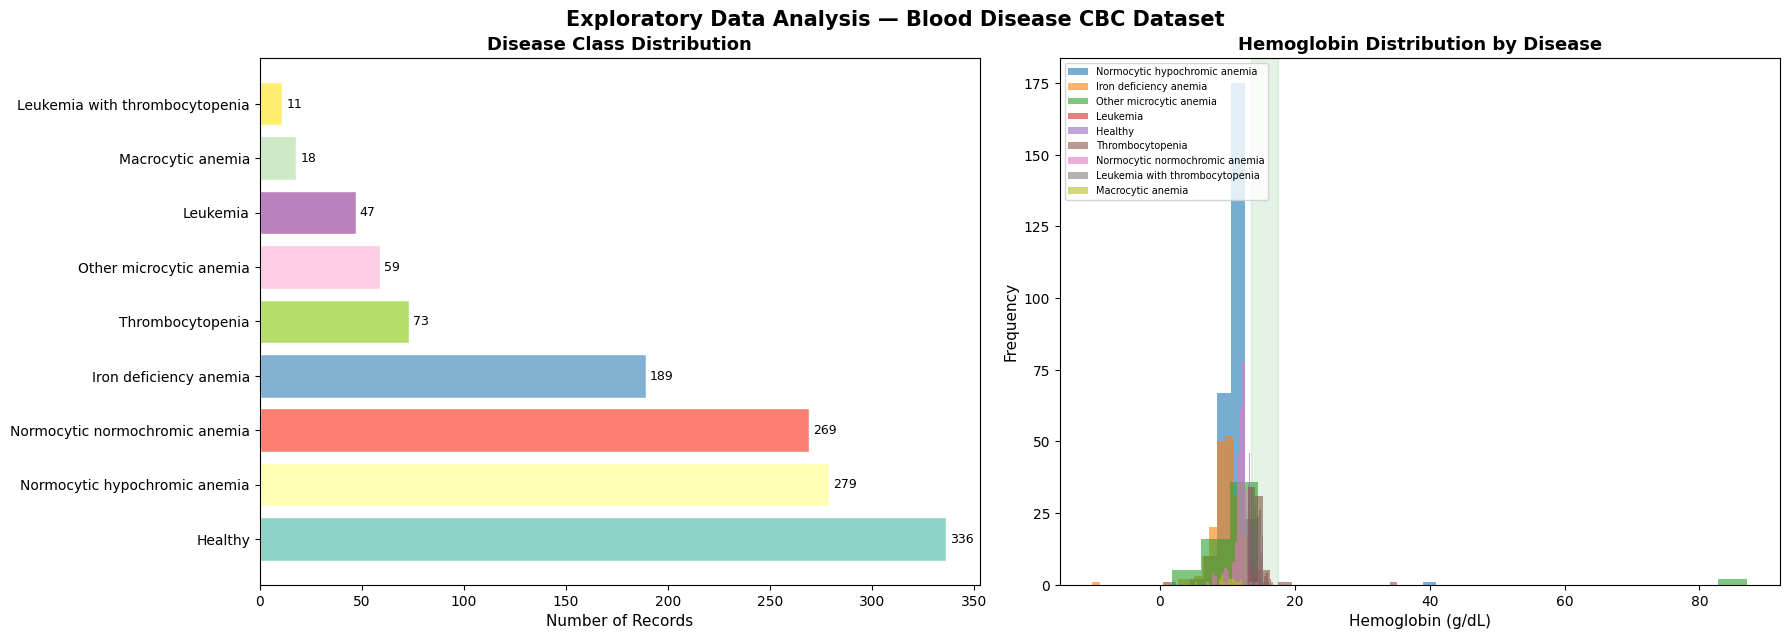

✅ EDA plots saved to /content/drive/MyDrive/BloodDiseaseML/plots/eda_plots.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Exploratory Data Analysis — Blood Disease CBC Dataset',
             fontsize=15, fontweight='bold')

# Disease distribution
ax = axes[0, 0]
counts = df_raw['Disease'].value_counts()
colors = plt.cm.Set3(np.linspace(0,1,len(counts)))
bars = ax.barh(counts.index, counts.values, color=colors, edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel('Number of Records', fontsize=11)
ax.set_title('Disease Class Distribution', fontsize=13, fontweight='bold')

# HGB distribution by disease
ax = axes[0, 1]
for disease in df_raw['Disease'].unique():
    subset = df_raw[df_raw['Disease'] == disease]['HGB']
    ax.hist(subset, bins=20, alpha=0.6, label=disease.replace(' Anemia','').replace('Megaloblastic ','Mega.'))
ax.set_xlabel('Hemoglobin (g/dL)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Hemoglobin Distribution by Disease', fontsize=13, fontweight='bold')
ax.legend(fontsize=7, loc='upper left')
ax.axvspan(13.5, 17.5, alpha=0.1, color='green', label='Normal range')

# WBC vs Lymphocytes scatter plot (only if 'LYM' is available)
if 'LYM' in df_raw.columns:
    ax = axes[1, 0]
    diseases = df_raw['Disease'].unique()
    palette  = plt.cm.tab10(np.linspace(0,1,len(diseases)))
    for i, disease in enumerate(diseases):
        sub = df_raw[df_raw['Disease'] == disease]
        ax.scatter(sub['WBC'], sub['LYM'], s=20, alpha=0.6, color=palette[i],
                   label=disease.split('(')[0].strip())
    ax.set_xlabel('WBC (×10³/µL)', fontsize=11)
    ax.set_ylabel('Lymphocytes (×10³/µL)', fontsize=11)
    ax.set_title('WBC vs Lymphocytes — Key Leukemia Indicator', fontsize=13, fontweight='bold')
    ax.legend(fontsize=7, loc='upper right')
    ax.axvline(11, color='red', linestyle='--', alpha=0.5, label='WBC upper limit')
else:
    fig.delaxes(axes[1, 0])
    print("ℹ️ Skipping 'WBC vs Lymphocytes' plot: 'LYM' column not found in dataset.")


# MCV vs RDW — key anemia differentiator (only if 'RDW' is available)
if 'RDW' in df_raw.columns:
    ax = axes[1, 1]
    diseases = df_raw['Disease'].unique()
    palette  = plt.cm.tab10(np.linspace(0,1,len(diseases)))
    for i, disease in enumerate(diseases):
        sub = df_raw[df_raw['Disease'] == disease]
        ax.scatter(sub['MCV'], sub['RDW'], s=20, alpha=0.6, color=palette[i],
                   label=disease.split('(')[0].strip())
    ax.set_xlabel('MCV (fL)', fontsize=11)
    ax.set_ylabel('RDW (%)', fontsize=11)
    ax.set_title('MCV vs RDW — Anemia Type Differentiator', fontsize=13, fontweight='bold')
    ax.legend(fontsize=7)
else:
    fig.delaxes(axes[1, 1])
    print("ℹ️ Skipping 'MCV vs RDW' plot: 'RDW' column not found in dataset.")

plt.tight_layout()
plot_path = os.path.join(PLOT_DIR, 'eda_plots.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ EDA plots saved to {plot_path}")

## 🔧 Preprocessing & Feature Engineering

In [14]:
# ── Keep available features ───────────────────────────────────────────
feat_cols = [c for c in FEATURE_COLS if c in df_raw.columns]
df = df_raw[feat_cols + ['Disease']].copy().dropna(subset=['Disease'])

# ── Impute missing values ─────────────────────────────────────────────
imputer = SimpleImputer(strategy='median')
df[feat_cols] = imputer.fit_transform(df[feat_cols])

# ── Encode labels ─────────────────────────────────────────────────────
le = LabelEncoder()
df['Disease_enc'] = le.fit_transform(df['Disease'])
CLASSES = list(le.classes_)

X = df[feat_cols].values
y = df['Disease_enc'].values

print(f"✅ Features used ({len(feat_cols)}): {feat_cols}")
print(f"✅ Total samples: {len(X)}")
print(f"✅ Classes ({len(CLASSES)}): {CLASSES}")

# ── Train / test split ────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

# ── SMOTE to balance training set ────────────────────────────────────
try:
    sm = SMOTE(random_state=RANDOM_STATE)
    X_train, y_train = sm.fit_resample(X_train, y_train)
    print(f"✅ SMOTE applied — training set size: {len(X_train)}")
except Exception as e:
    print(f"ℹ️  SMOTE skipped: {e}")

print(f"✅ Train: {X_train.shape}   Test: {X_test.shape}")

✅ Features used (8): ['WBC', 'RBC', 'HGB', 'HCT', 'MCV', 'MCH', 'MCHC', 'PLT']
✅ Total samples: 1281
✅ Classes (9): ['Healthy', 'Iron deficiency anemia', 'Leukemia', 'Leukemia with thrombocytopenia', 'Macrocytic anemia', 'Normocytic hypochromic anemia', 'Normocytic normochromic anemia', 'Other microcytic anemia', 'Thrombocytopenia']
✅ SMOTE applied — training set size: 2421
✅ Train: (2421, 8)   Test: (257, 8)


## 🔥 Feature Correlation Heatmap

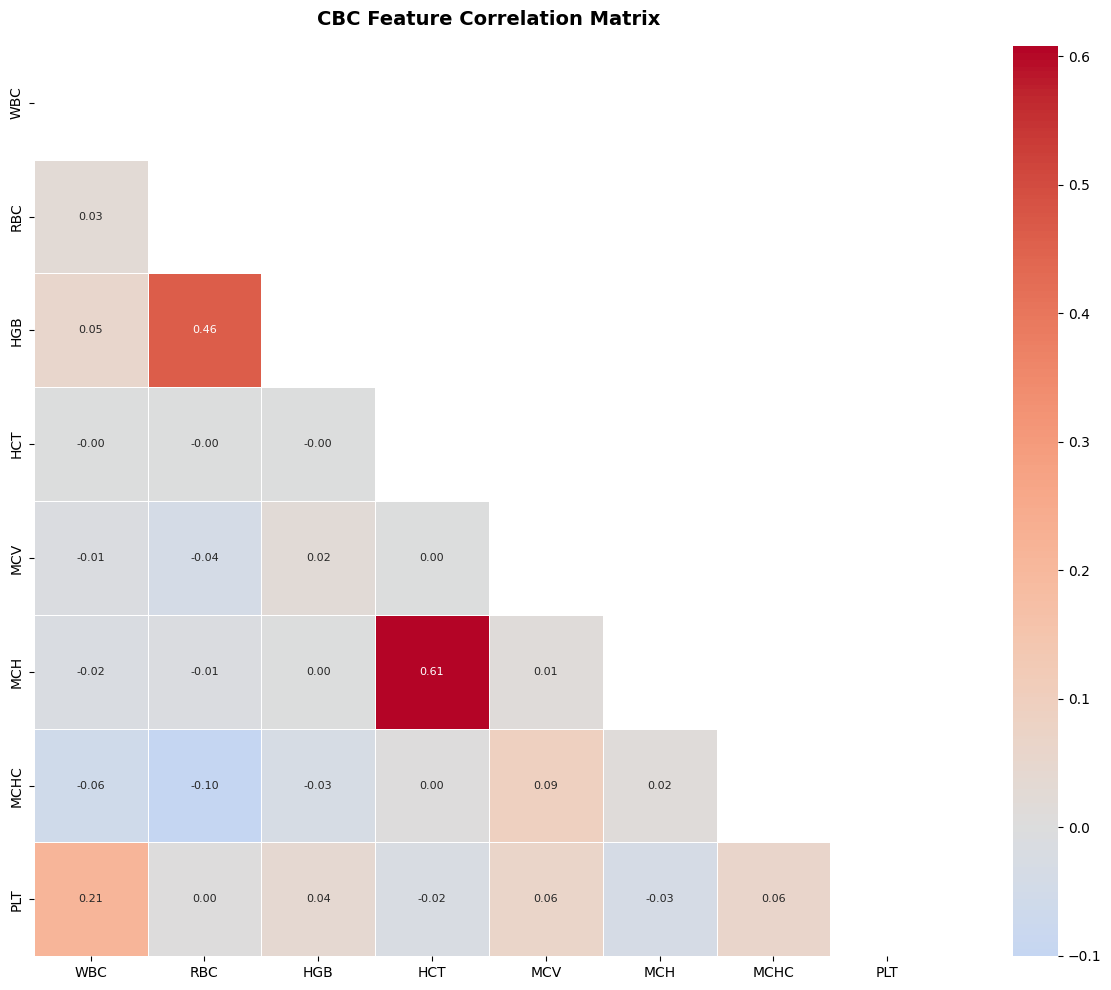

✅ Correlation heatmap saved.


In [15]:
fig, ax = plt.subplots(figsize=(14, 10))
corr = df[feat_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('CBC Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Correlation heatmap saved.")

## 🤖 Train & Compare ML Models

In [16]:
models = {
    'Random Forest':
        RandomForestClassifier(n_estimators=300, max_features='sqrt',
                               class_weight='balanced', random_state=RANDOM_STATE),
    'Gradient Boosting':
        GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                   random_state=RANDOM_STATE),
    'SVM (RBF Kernel)':
        Pipeline([('scaler', StandardScaler()),
                  ('svm', SVC(C=10, gamma='scale', probability=True,
                              class_weight='balanced', random_state=RANDOM_STATE))]),
    'Logistic Regression':
        Pipeline([('scaler', StandardScaler()),
                  ('lr',  LogisticRegression(C=1.0, max_iter=1000,
                                             class_weight='balanced',
                                             random_state=RANDOM_STATE))]),
    'K-Nearest Neighbors':
        Pipeline([('scaler', StandardScaler()),
                  ('knn', KNeighborsClassifier(n_neighbors=7, weights='distance'))]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

print("Training models with 5-fold cross-validation...\n")
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv,
                             scoring='accuracy', n_jobs=-1)
    cv_results[name] = {'model': model, 'mean': scores.mean(), 'std': scores.std()}
    bar = '█' * int(scores.mean() * 40)
    print(f"  {name:<26}  {bar}  {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%")

BEST_NAME  = max(cv_results, key=lambda k: cv_results[k]['mean'])
BEST_MODEL = cv_results[BEST_NAME]['model']
BEST_MODEL.fit(X_train, y_train)

print(f"\n🏆 Best model: {BEST_NAME}  (CV accuracy = {cv_results[BEST_NAME]['mean']*100:.2f}%)")

# Save model + metadata to Drive
joblib.dump(BEST_MODEL, MODEL_PKL)
joblib.dump({'classes': CLASSES, 'features': feat_cols, 'best_name': BEST_NAME}, META_PKL)
print(f"✅ Model saved to: {MODEL_PKL}")

Training models with 5-fold cross-validation...

  Random Forest               ███████████████████████████████████████  99.67% ± 0.36%
  Gradient Boosting           ███████████████████████████████████████  99.50% ± 0.53%
  SVM (RBF Kernel)            █████████████████████████████████████  94.80% ± 0.94%
  Logistic Regression         ██████████████████████████████████  86.08% ± 1.31%
  K-Nearest Neighbors         ████████████████████████████████████  91.37% ± 0.41%

🏆 Best model: Random Forest  (CV accuracy = 99.67%)
✅ Model saved to: /content/drive/MyDrive/BloodDiseaseML/models/best_model.pkl


## 📈 Model Evaluation & Visualisations

In [17]:
y_pred = BEST_MODEL.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f"\n{'='*60}")
print(f"  TEST SET ACCURACY: {acc*100:.2f}%")
print(f"{'='*60}")
print(classification_report(y_test, y_pred, target_names=CLASSES))


  TEST SET ACCURACY: 99.22%
                                precision    recall  f1-score   support

                       Healthy       1.00      1.00      1.00        67
        Iron deficiency anemia       0.97      0.97      0.97        38
                      Leukemia       1.00      1.00      1.00         9
Leukemia with thrombocytopenia       1.00      1.00      1.00         2
             Macrocytic anemia       1.00      1.00      1.00         4
 Normocytic hypochromic anemia       0.98      1.00      0.99        56
Normocytic normochromic anemia       1.00      1.00      1.00        54
       Other microcytic anemia       1.00      0.92      0.96        12
              Thrombocytopenia       1.00      1.00      1.00        15

                      accuracy                           0.99       257
                     macro avg       1.00      0.99      0.99       257
                  weighted avg       0.99      0.99      0.99       257



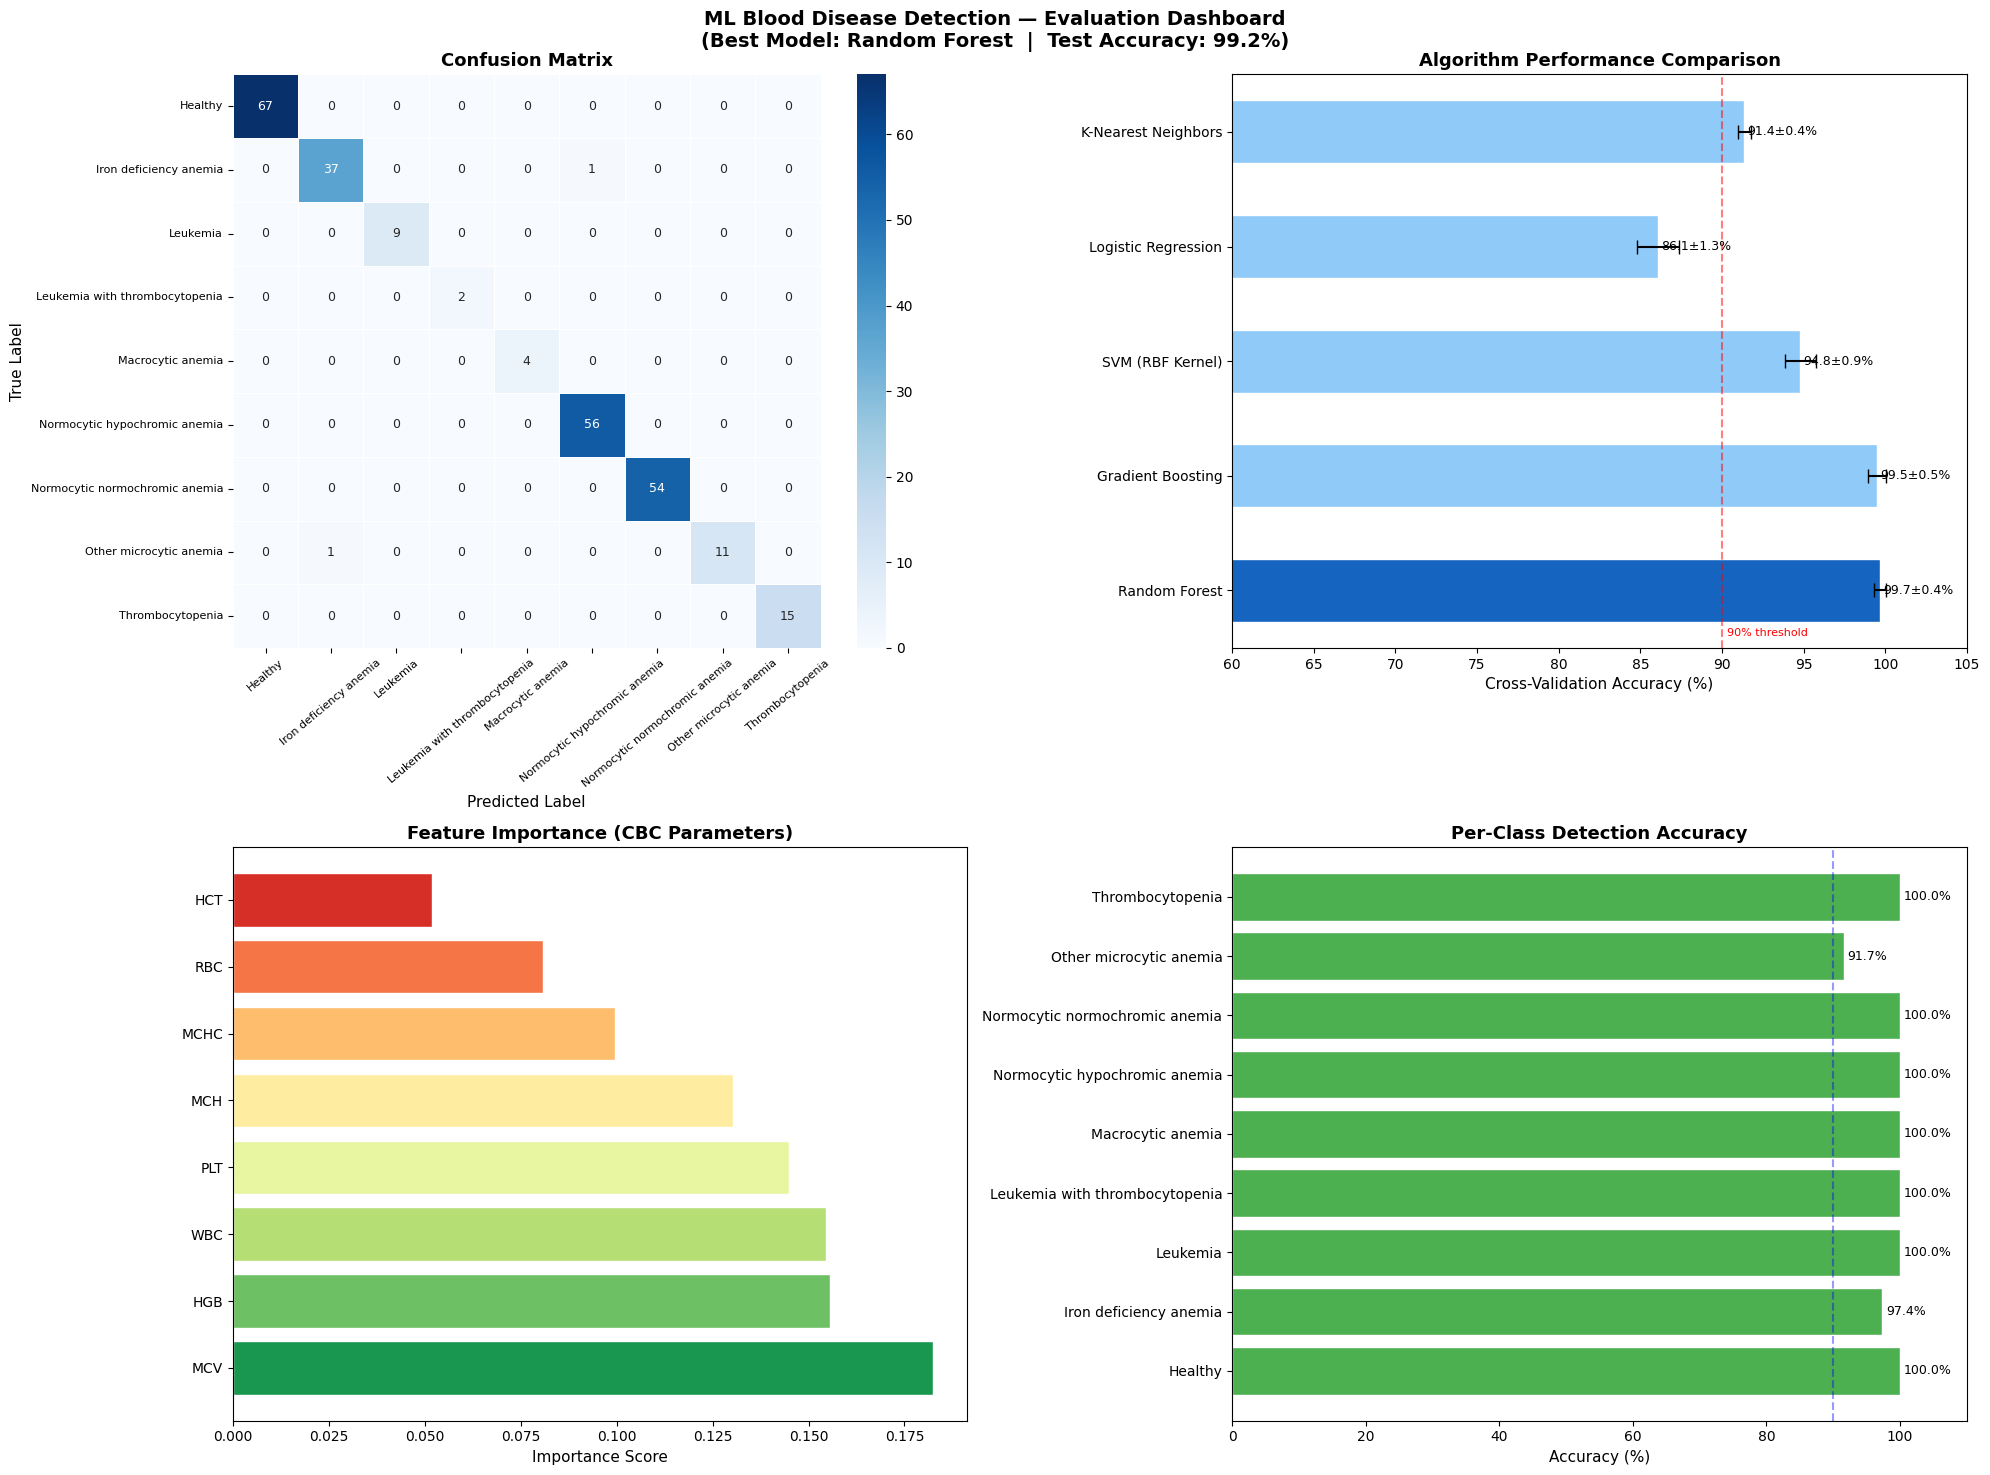

✅ Evaluation dashboard saved to Drive.


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle(f'ML Blood Disease Detection — Evaluation Dashboard\n(Best Model: {BEST_NAME}  |  Test Accuracy: {acc*100:.1f}%)',
             fontsize=14, fontweight='bold', y=0.98)

SHORT = [c.replace(' Anemia','').replace(' (Suspected)','').replace('Megaloblastic ','Mega.').replace('Deficiency','Def.')
         for c in CLASSES]

# ── Confusion Matrix ─────────────────────────────────────────────────
ax = axes[0, 0]
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=SHORT, yticklabels=SHORT, linewidths=0.5,
            annot_kws={'size': 9})
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=40, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)

# ── Model Comparison Bar Chart ───────────────────────────────────────
ax = axes[0, 1]
names  = list(cv_results.keys())
means  = [cv_results[n]['mean']*100 for n in names]
stds   = [cv_results[n]['std']*100  for n in names]
clrs   = ['#1565C0' if n == BEST_NAME else '#90CAF9' for n in names]
bars   = ax.barh(names, means, xerr=stds, color=clrs, capsize=5,
                 edgecolor='white', height=0.55)
for bar, v, s in zip(bars, means, stds):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f"{v:.1f}±{s:.1f}%", va='center', fontsize=9)
ax.set_xlabel('Cross-Validation Accuracy (%)', fontsize=11)
ax.set_title('Algorithm Performance Comparison', fontsize=13, fontweight='bold')
ax.set_xlim(60, 105)
ax.axvline(90, color='red', linestyle='--', alpha=0.5)
ax.text(90.3, -0.4, '90% threshold', fontsize=8, color='red')

# ── Feature Importance ───────────────────────────────────────────────
ax = axes[1, 0]
if hasattr(BEST_MODEL, 'feature_importances_'):
    importances = BEST_MODEL.feature_importances_
elif hasattr(BEST_MODEL, 'named_steps'):
    inner = list(BEST_MODEL.named_steps.values())[-1]
    if hasattr(inner, 'feature_importances_'):
        importances = inner.feature_importances_
    elif hasattr(inner, 'coef_'):
        importances = np.abs(inner.coef_).mean(axis=0)
    else:
        importances = np.ones(len(feat_cols)) / len(feat_cols)
else:
    importances = np.ones(len(feat_cols)) / len(feat_cols)

idx = np.argsort(importances)[::-1]
palette = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(feat_cols)))
ax.barh([feat_cols[i] for i in idx], importances[idx],
        color=[palette[r] for r in range(len(feat_cols))], edgecolor='white')
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_title('Feature Importance (CBC Parameters)', fontsize=13, fontweight='bold')

# ── Per-Class Accuracy ───────────────────────────────────────────────
ax = axes[1, 1]
per_class_acc = []
for i, cls in enumerate(CLASSES):
    mask = y_test == i
    if mask.sum() > 0:
        per_class_acc.append(accuracy_score(y_test[mask], y_pred[mask]))
    else:
        per_class_acc.append(0)
colors_c = ['#4CAF50' if a >= 0.9 else '#FF9800' if a >= 0.75 else '#F44336' for a in per_class_acc]
bars2 = ax.barh(SHORT, [a*100 for a in per_class_acc], color=colors_c, edgecolor='white')
for bar, val in zip(bars2, per_class_acc):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f"{val*100:.1f}%", va='center', fontsize=9)
ax.set_xlabel('Accuracy (%)', fontsize=11)
ax.set_title('Per-Class Detection Accuracy', fontsize=13, fontweight='bold')
ax.set_xlim(0, 110)
ax.axvline(90, color='blue', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'evaluation_dashboard.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Evaluation dashboard saved to Drive.")

## 🏥 Patient Diagnosis Engine
This cell defines the full diagnosis and prescription function. Run it once, then proceed to Demo patient cases.

In [19]:
def diagnose_patient(patient_data, model=BEST_MODEL, classes=CLASSES, features=feat_cols):
    """Run model on patient_data dict and print a full diagnostic report."""

    # ── Build feature vector ──────────────────────────────────────────
    X_patient = np.array([[patient_data.get(f, (NORMAL_RANGES[f][0]+NORMAL_RANGES[f][1])/2)
                           for f in features]])

    proba     = model.predict_proba(X_patient)[0]
    pred_idx  = int(np.argmax(proba))
    pred_label = classes[pred_idx]
    confidence = proba[pred_idx]
    ranked     = sorted(enumerate(proba), key=lambda x: -x[1])

    # ── Abnormal flags ────────────────────────────────────────────────
    flags = []
    for param, val in patient_data.items():
        if param not in NORMAL_RANGES: continue
        lo, hi, unit = NORMAL_RANGES[param]
        if val < lo:   flags.append((param, val, unit, '⬇ LOW',  'red'))
        elif val > hi: flags.append((param, val, unit, '⬆ HIGH', 'orange'))

    # ══════════════════ VISUAL REPORT ════════════════════════════════
    fig = plt.figure(figsize=(20, 14))
    fig.patch.set_facecolor('#0D1117')

    # Title band
    ax_title = fig.add_axes([0, 0.93, 1, 0.07])
    ax_title.set_facecolor('#161B22'); ax_title.axis('off')
    ax_title.text(0.5, 0.55, '🩸  BLOOD DISEASE DIAGNOSTIC REPORT',
                  ha='center', va='center', fontsize=18, fontweight='bold',
                  color='white', transform=ax_title.transAxes)

    # ── CBC Table (left panel) ────────────────────────────────────────
    ax_tbl = fig.add_axes([0.01, 0.02, 0.33, 0.88])
    ax_tbl.set_facecolor('#161B22'); ax_tbl.axis('off')
    ax_tbl.set_title('CBC Values', color='white', fontsize=13, fontweight='bold', pad=8)

    rows, row_colors = [], []
    for param in features:
        val = patient_data.get(param, None)
        if val is None: continue
        lo, hi, unit = NORMAL_RANGES.get(param, (0, 9999, ''))
        if   val < lo: status, col = '⬇ LOW',  '#FF6B6B'
        elif val > hi: status, col = '⬆ HIGH', '#FFD93D'
        else:          status, col = '✓ Normal','#6BCB77'
        rows.append([param, f"{val:.2f}", unit, status])
        row_colors.append(['#1C2128','#1C2128','#1C2128', col])

    tbl = ax_tbl.table(cellText=rows,
                       colLabels=['Parameter','Value','Unit','Status'],
                       cellLoc='center', loc='center',
                       cellColours=row_colors)
    tbl.auto_set_font_size(False); tbl.set_fontsize(9.5)
    tbl.scale(1, 1.55)
    for (r, c), cell in tbl.get_celld().items():
        cell.set_text_props(color='white')
        cell.set_edgecolor('#30363D')
        if r == 0:
            cell.set_facecolor('#21262D')
            cell.set_text_props(fontweight='bold', color='#58A6FF')

    # ── Diagnosis Panel (middle) ──────────────────────────────────────
    ax_dx = fig.add_axes([0.36, 0.50, 0.30, 0.40])
    ax_dx.set_facecolor('#161B22'); ax_dx.axis('off')

    ax_dx.text(0.5, 0.95, '🔬 PRIMARY DIAGNOSIS', ha='center', va='top',
               fontsize=12, fontweight='bold', color='#58A6FF', transform=ax_dx.transAxes)
    ax_dx.text(0.5, 0.80, pred_label, ha='center', va='top',
               fontsize=13, fontweight='bold', color='white', transform=ax_dx.transAxes,
               wrap=True)

    # Confidence gauge
    conf_color = '#4CAF50' if confidence > 0.75 else '#FF9800' if confidence > 0.50 else '#F44336'
    ax_dx.text(0.5, 0.62, f'Confidence: {confidence*100:.1f}%', ha='center', va='top',
               fontsize=11, color=conf_color, transform=ax_dx.transAxes, fontweight='bold')

    # Gauge bar
    ax_gauge = fig.add_axes([0.38, 0.56, 0.26, 0.035])
    ax_gauge.set_facecolor('#21262D')
    ax_gauge.barh(0, confidence, color=conf_color, height=0.8)
    ax_gauge.barh(0, 1-confidence, left=confidence, color='#30363D', height=0.8)
    ax_gauge.set_xlim(0,1); ax_gauge.axis('off')

    # Differentials
    ax_dx.text(0.5, 0.50, '─── Differential Diagnoses ───', ha='center',
               fontsize=10, color='#8B949E', transform=ax_dx.transAxes)
    for rank, (idx_r, prob) in enumerate(ranked[:3], 1):
        icon = '→' if rank == 1 else ' '
        col  = '#58A6FF' if rank == 1 else '#8B949E'
        ax_dx.text(0.05, 0.44 - (rank-1)*0.12,
                   f"{icon} {rank}. {classes[idx_r]}", fontsize=8.5, color=col,
                   transform=ax_dx.transAxes)
        ax_dx.text(0.92, 0.44 - (rank-1)*0.12,
                   f"{prob*100:.1f}%", fontsize=8.5, color=col, ha='right',
                   transform=ax_dx.transAxes)

    # ── Probability donut ─────────────────────────────────────────────
    ax_donut = fig.add_axes([0.36, 0.02, 0.30, 0.44])
    ax_donut.set_facecolor('#161B22')
    top5_idx  = [r[0] for r in ranked[:5]]
    top5_prob = [proba[i] for i in top5_idx]
    rest_prob = 1 - sum(top5_prob)
    labels_d  = [classes[i].split('(')[0][:20].strip() for i in top5_idx] + (['Other'] if rest_prob > 0.001 else [])
    sizes_d   = top5_prob + ([rest_prob] if rest_prob > 0.001 else [])
    palette_d = ['#58A6FF','#3FB950','#F78166','#D29922','#A371F7','#8B949E']
    wedges, _, autotexts = ax_donut.pie(
        sizes_d, labels=None, autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
        colors=palette_d[:len(sizes_d)], startangle=90,
        wedgeprops={'width':0.55,'edgecolor':'#0D1117','linewidth':2},
        pctdistance=0.78)
    for at in autotexts: at.set_color('white'); at.set_fontsize(8)
    ax_donut.legend(wedges, labels_d, loc='lower center', bbox_to_anchor=(0.5,-0.12),
                    ncol=2, fontsize=8, labelcolor='white',
                    facecolor='#1C2128', edgecolor='#30363D')
    ax_donut.set_title('Probability Distribution', color='white', fontsize=11,
                        fontweight='bold', pad=5)

    # ── Prescription Panel (right) ────────────────────────────────────
    ax_rx = fig.add_axes([0.68, 0.02, 0.31, 0.88])
    ax_rx.set_facecolor('#161B22'); ax_rx.axis('off')
    ax_rx.set_title('💊 Prescription & Management Plan', color='#58A6FF',
                     fontsize=12, fontweight='bold', pad=8)

    rx    = PRESCRIPTION_DB.get(pred_label, PRESCRIPTION_DB['Healthy / Normal'])
    y_pos = 0.97

    def rx_section(ax, title, items, y, icon=''):
        ax.text(0.02, y, f'{icon} {title}', transform=ax.transAxes,
                fontsize=10, fontweight='bold', color='#F0883E',
                verticalalignment='top')
        y -= 0.05
        for item in items:
            # word-wrap long items
            words = item.split()
            line, lines = '', []
            for w in words:
                if len(line + ' ' + w) > 48: lines.append(line); line = w
                else: line = (line + ' ' + w).strip()
            if line: lines.append(line)
            for l in lines:
                ax.text(0.04, y, f'• {l}', transform=ax.transAxes,
                        fontsize=8.2, color='#C9D1D9', verticalalignment='top')
                y -= 0.038
            y -= 0.005
        return y

    y_pos = rx_section(ax_rx, 'MEDICATIONS',            rx['medications'], y_pos, '💊')
    y_pos -= 0.02
    y_pos = rx_section(ax_rx, 'DIETARY ADVICE',         rx['dietary'],     y_pos, '🥗')
    y_pos -= 0.02
    y_pos = rx_section(ax_rx, 'LIFESTYLE',              rx['lifestyle'],   y_pos, '🏃')
    y_pos -= 0.02
    ax_rx.text(0.02, y_pos, '📅 FOLLOW-UP:', transform=ax_rx.transAxes,
               fontsize=10, fontweight='bold', color='#F0883E', verticalalignment='top')
    ax_rx.text(0.04, y_pos-0.045, rx['followup'], transform=ax_rx.transAxes,
               fontsize=8.2, color='#C9D1D9', verticalalignment='top')

    # Disclaimer
    ax_disc = fig.add_axes([0, 0, 1, 0.025])
    ax_disc.set_facecolor('#21262D'); ax_disc.axis('off')
    ax_disc.text(0.5, 0.5, '⚕ DISCLAIMER: This system is a clinical decision-support tool only. '
                 'All results must be reviewed and confirmed by a qualified physician.',
                 ha='center', va='center', fontsize=8.5, color='#8B949E',
                 transform=ax_disc.transAxes)

    plt.savefig(os.path.join(PLOT_DIR, 'patient_report.png'),
                dpi=150, bbox_inches='tight', facecolor='#0D1117')
    plt.show()

    # ── Console summary ───────────────────────────────────────────────
    print(f"\n{'='*60}")
    print(f"  🔬 DIAGNOSIS : {pred_label}")
    print(f"  📊 CONFIDENCE: {confidence*100:.1f}%")
    print(f"{'='*60}")
    if flags:
        print("\n  ⚠ ABNORMAL VALUES:")
        for param, val, unit, flag, _ in flags:
            lo, hi, _ = NORMAL_RANGES[param]
            print(f"     {flag} {param}: {val} {unit}  (normal: {lo}–{hi})")
    print(f"\n  💊 KEY MEDICATIONS:")
    for m in rx['medications'][:3]: print(f"     • {m}")
    print(f"\n  📅 FOLLOW-UP: {rx['followup']}")
    print(f"{'='*60}")

    return pred_label, confidence

print("✅ diagnose_patient() function ready.")

✅ diagnose_patient() function ready.


## 🧪 Demo: Predefined Patient Cases
Run any of the sub-cells below to see an instant diagnosis.

🧪 Demo Patient 1: Iron Deficiency Anemia


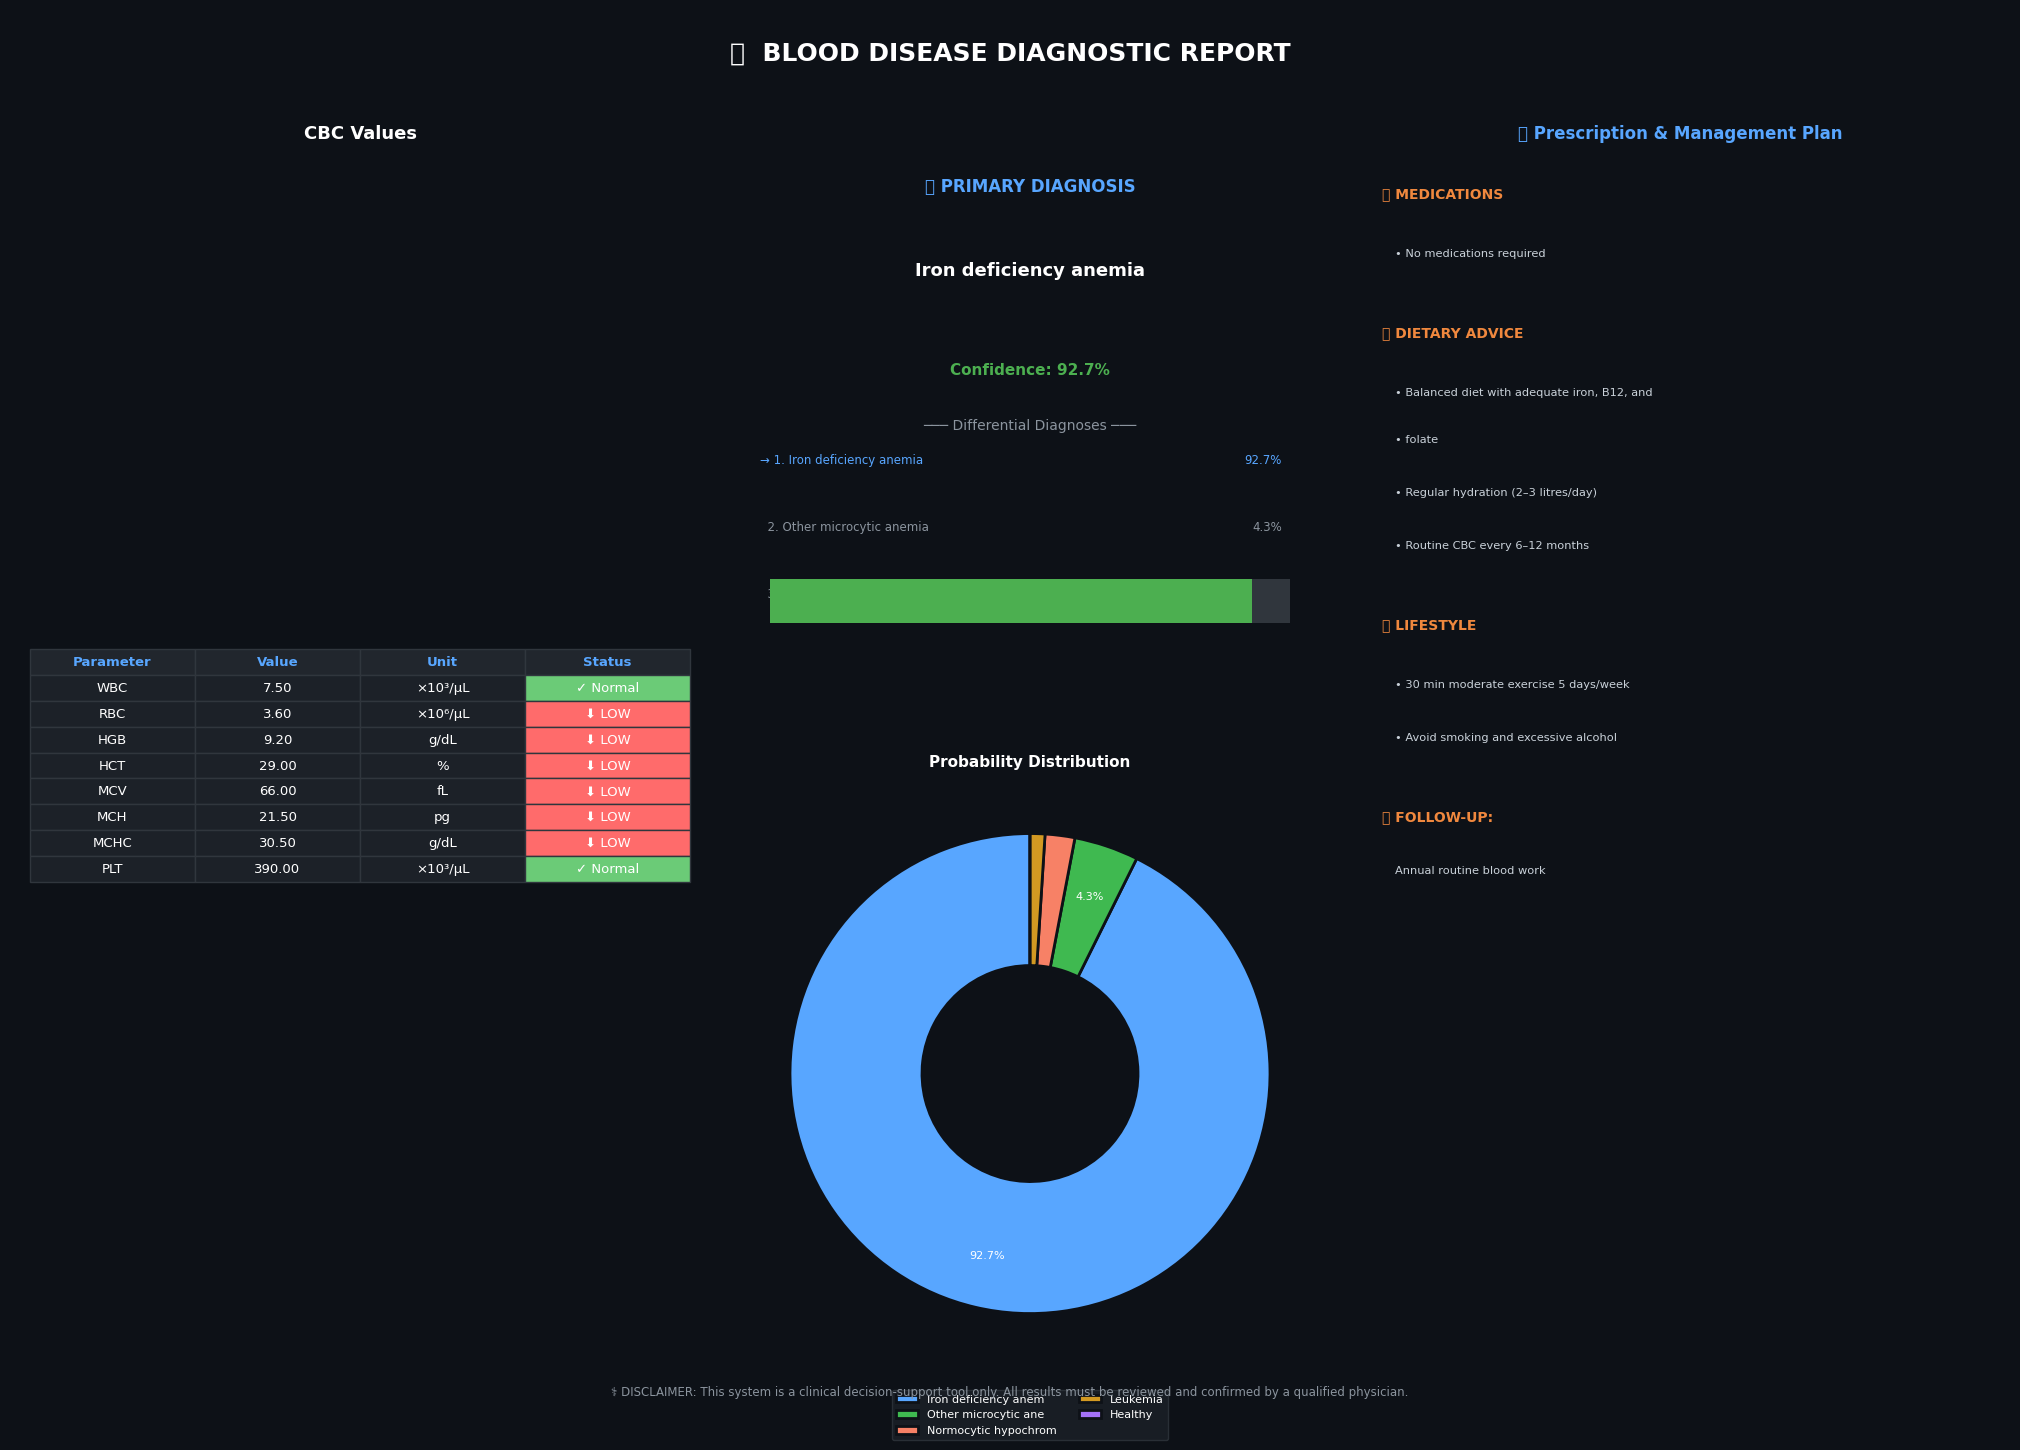


  🔬 DIAGNOSIS : Iron deficiency anemia
  📊 CONFIDENCE: 92.7%

  ⚠ ABNORMAL VALUES:
     ⬇ LOW RBC: 3.6 ×10⁶/µL  (normal: 4.5–5.5)
     ⬇ LOW HGB: 9.2 g/dL  (normal: 13.5–17.5)
     ⬇ LOW HCT: 29.0 %  (normal: 41.0–53.0)
     ⬇ LOW MCV: 66.0 fL  (normal: 80.0–100.0)
     ⬇ LOW MCH: 21.5 pg  (normal: 27.0–33.0)
     ⬇ LOW MCHC: 30.5 g/dL  (normal: 32.0–36.0)
     ⬆ HIGH RDW: 17.2 %  (normal: 11.5–14.5)

  💊 KEY MEDICATIONS:
     • No medications required

  📅 FOLLOW-UP: Annual routine blood work


('Iron deficiency anemia', np.float64(0.9266666666666666))

In [20]:
# ── Demo 1: Iron Deficiency Anemia ───────────────────────────────────
patient_IDA = {
    'WBC': 7.5,  'RBC': 3.6,  'HGB': 9.2,  'HCT': 29.0,
    'MCV': 66.0, 'MCH': 21.5, 'MCHC': 30.5,'PLT': 390.0,
    'NEU': 5.0,  'LYM': 2.1,  'MON': 0.45, 'EOS': 0.15,
    'BAS': 0.04, 'RDW': 17.2, 'MPV': 11.8
}
print("🧪 Demo Patient 1: Iron Deficiency Anemia")
diagnose_patient(patient_IDA)

🧪 Demo Patient 2: Leukemia (Suspected)


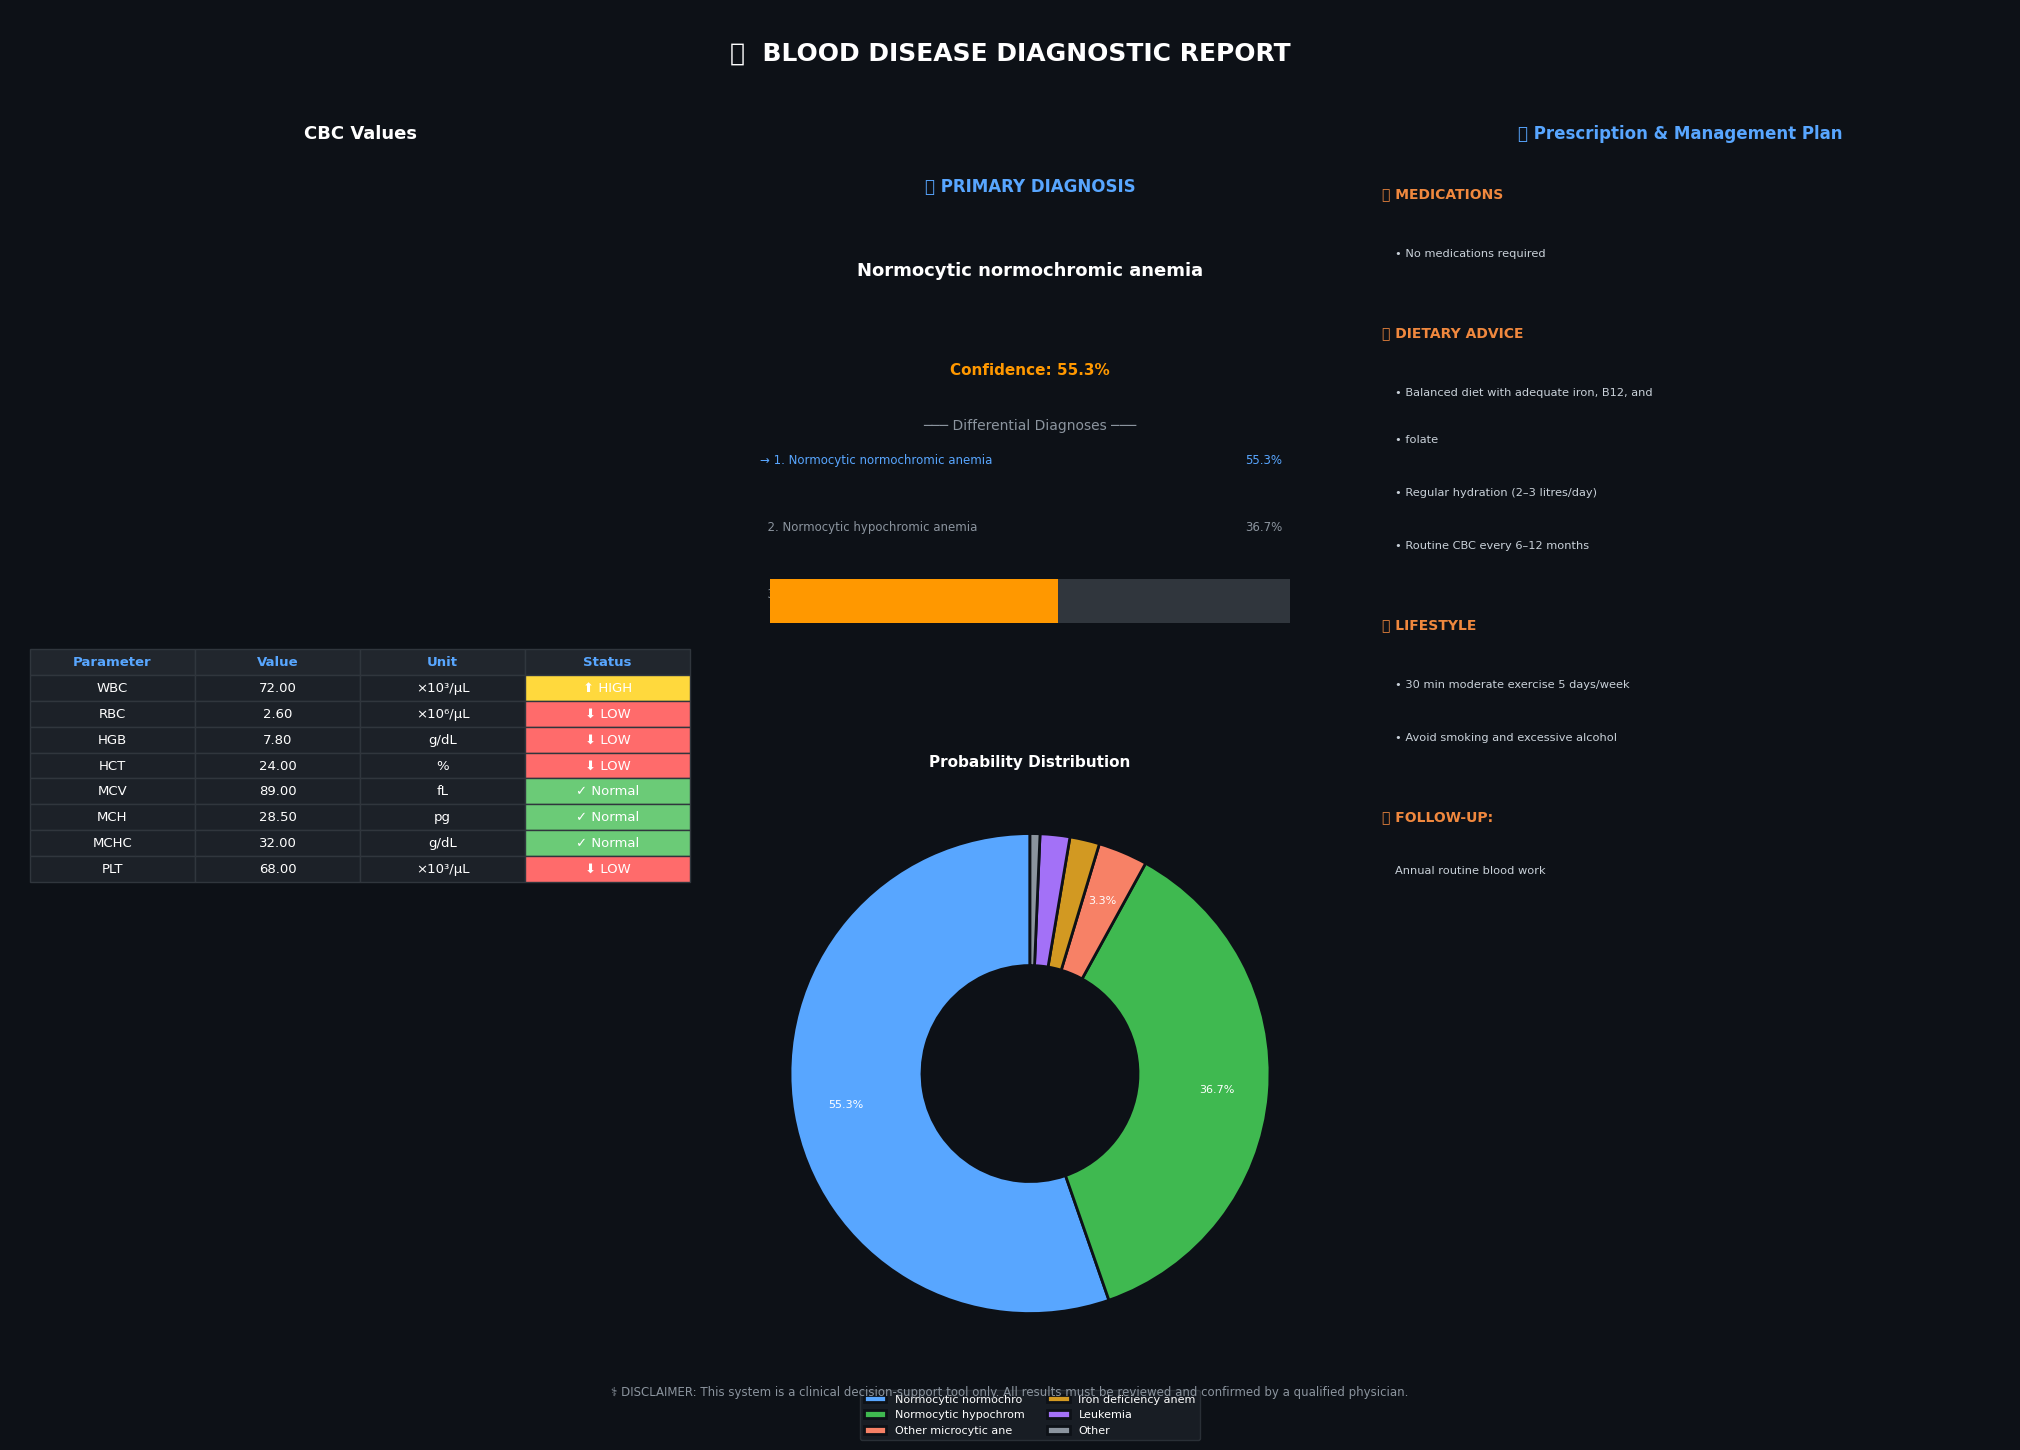


  🔬 DIAGNOSIS : Normocytic normochromic anemia
  📊 CONFIDENCE: 55.3%

  ⚠ ABNORMAL VALUES:
     ⬆ HIGH WBC: 72.0 ×10³/µL  (normal: 4.0–11.0)
     ⬇ LOW RBC: 2.6 ×10⁶/µL  (normal: 4.5–5.5)
     ⬇ LOW HGB: 7.8 g/dL  (normal: 13.5–17.5)
     ⬇ LOW HCT: 24.0 %  (normal: 41.0–53.0)
     ⬇ LOW PLT: 68.0 ×10³/µL  (normal: 150.0–400.0)
     ⬆ HIGH LYM: 62.0 ×10³/µL  (normal: 1.0–4.8)
     ⬆ HIGH MON: 2.0 ×10³/µL  (normal: 0.2–1.0)
     ⬆ HIGH EOS: 0.6 ×10³/µL  (normal: 0.0–0.5)
     ⬆ HIGH BAS: 0.25 ×10³/µL  (normal: 0.0–0.1)
     ⬆ HIGH RDW: 17.0 %  (normal: 11.5–14.5)

  💊 KEY MEDICATIONS:
     • No medications required

  📅 FOLLOW-UP: Annual routine blood work


('Normocytic normochromic anemia', np.float64(0.5533333333333333))

In [21]:
# ── Demo 2: Leukemia (Suspected) ─────────────────────────────────────
patient_LEU = {
    'WBC': 72.0, 'RBC': 2.6,  'HGB': 7.8,  'HCT': 24.0,
    'MCV': 89.0, 'MCH': 28.5, 'MCHC': 32.0,'PLT': 68.0,
    'NEU': 1.8,  'LYM': 62.0, 'MON': 2.0,  'EOS': 0.6,
    'BAS': 0.25, 'RDW': 17.0, 'MPV': 8.2
}
print("🧪 Demo Patient 2: Leukemia (Suspected)")
diagnose_patient(patient_LEU)

🧪 Demo Patient 3: Sickle Cell Disease


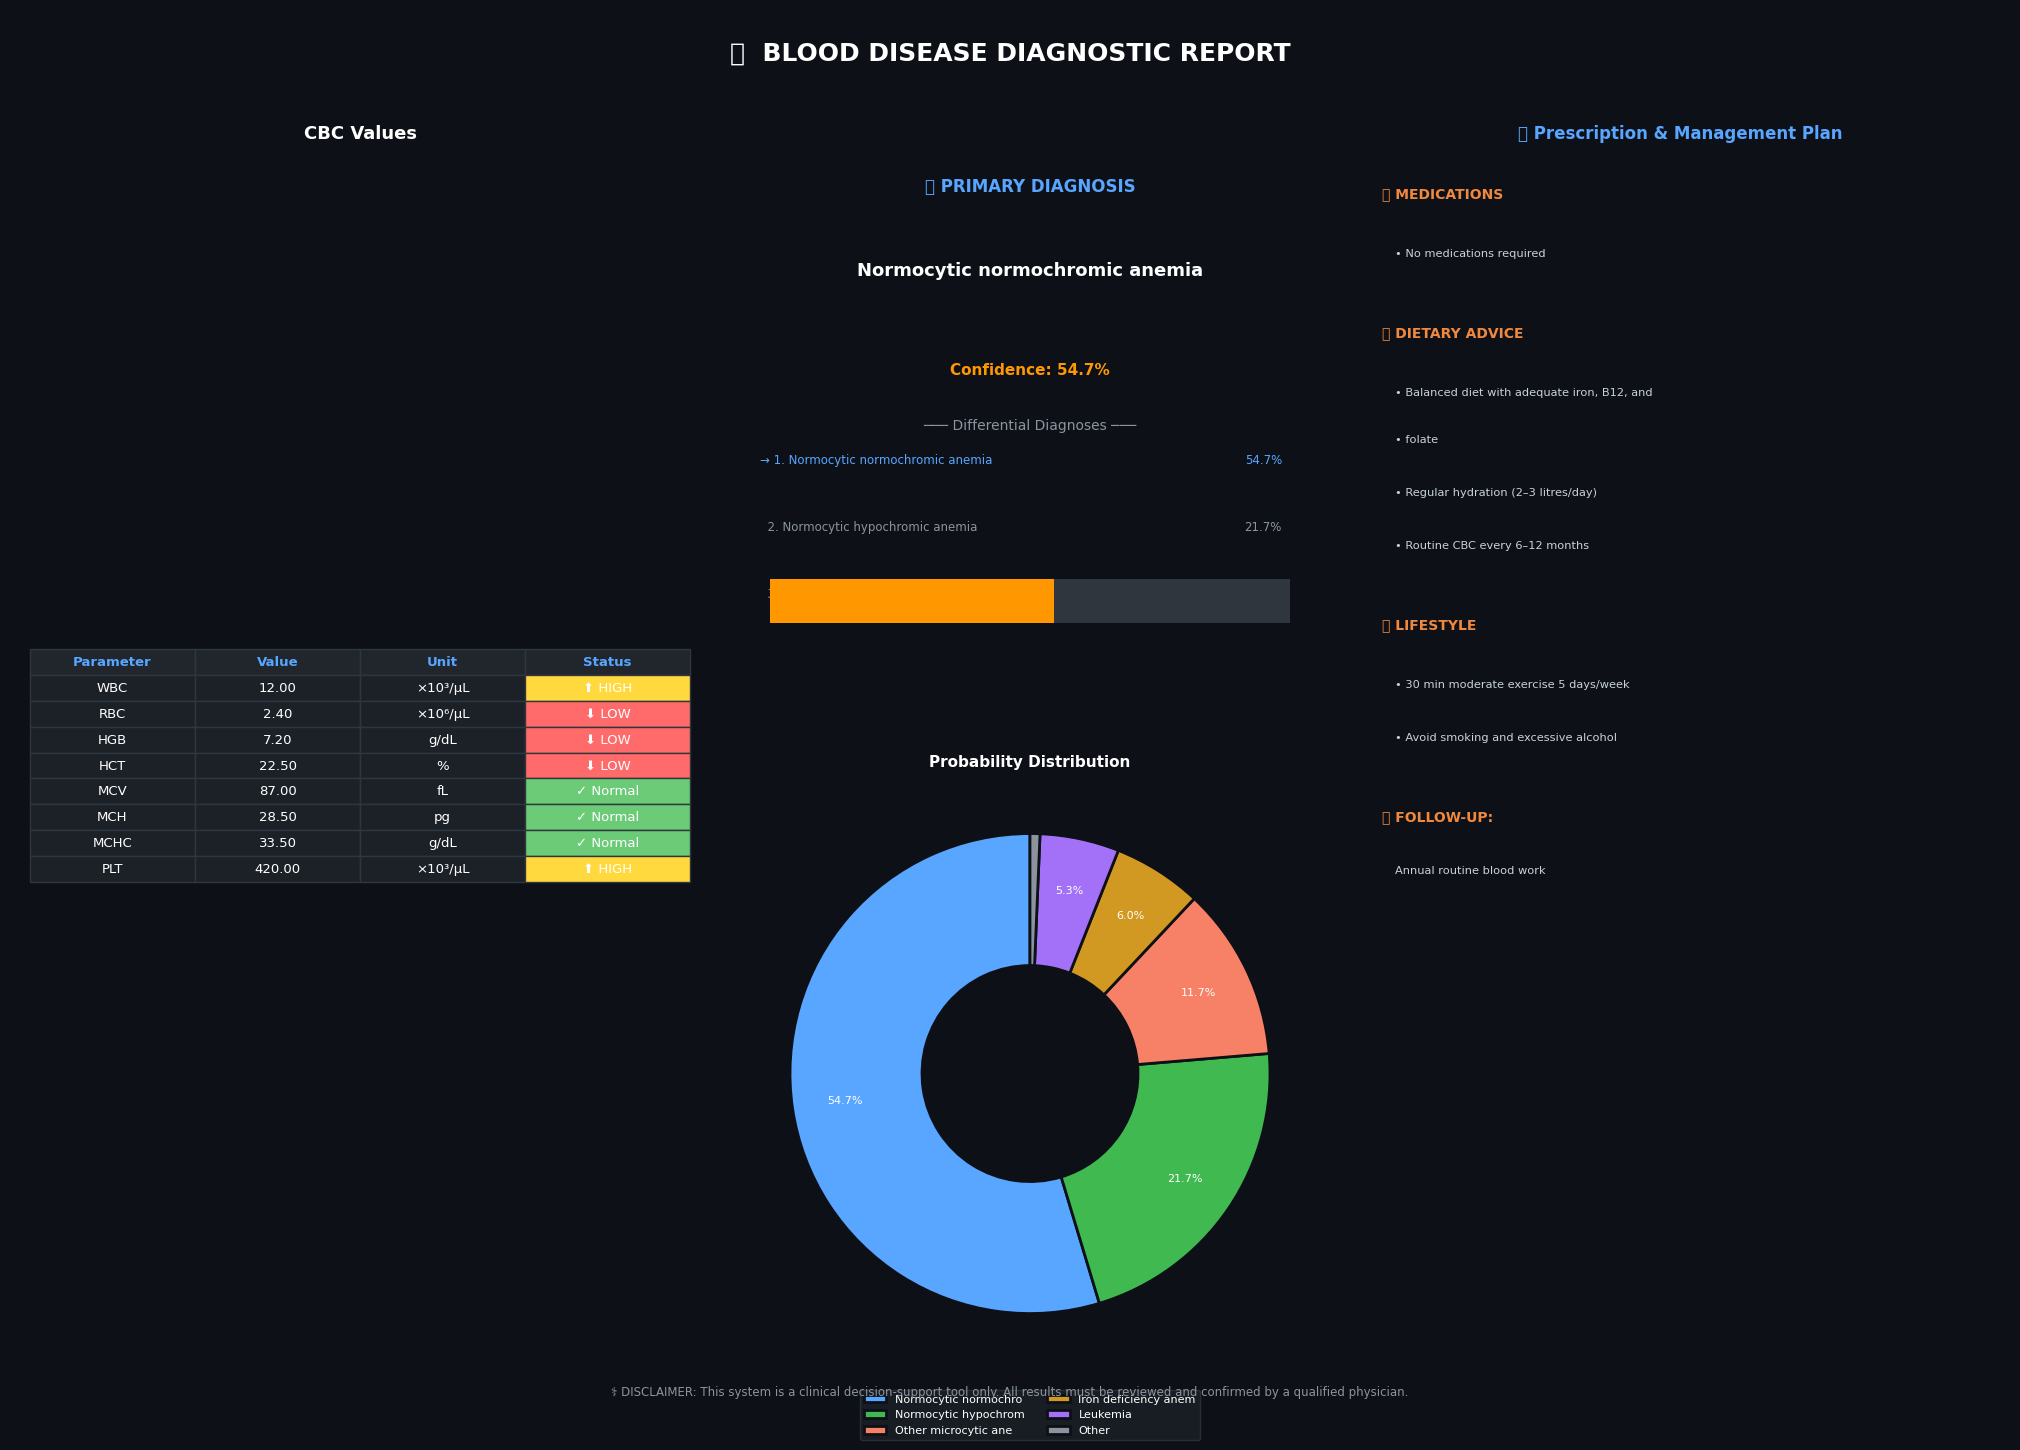


  🔬 DIAGNOSIS : Normocytic normochromic anemia
  📊 CONFIDENCE: 54.7%

  ⚠ ABNORMAL VALUES:
     ⬆ HIGH WBC: 12.0 ×10³/µL  (normal: 4.0–11.0)
     ⬇ LOW RBC: 2.4 ×10⁶/µL  (normal: 4.5–5.5)
     ⬇ LOW HGB: 7.2 g/dL  (normal: 13.5–17.5)
     ⬇ LOW HCT: 22.5 %  (normal: 41.0–53.0)
     ⬆ HIGH PLT: 420.0 ×10³/µL  (normal: 150.0–400.0)
     ⬆ HIGH RDW: 21.5 %  (normal: 11.5–14.5)

  💊 KEY MEDICATIONS:
     • No medications required

  📅 FOLLOW-UP: Annual routine blood work


('Normocytic normochromic anemia', np.float64(0.5466666666666666))

In [22]:
# ── Demo 3: Sickle Cell Disease ──────────────────────────────────────
patient_SCD = {
    'WBC': 12.0, 'RBC': 2.4,  'HGB': 7.2,  'HCT': 22.5,
    'MCV': 87.0, 'MCH': 28.5, 'MCHC': 33.5,'PLT': 420.0,
    'NEU': 7.0,  'LYM': 3.2,  'MON': 0.75, 'EOS': 0.32,
    'BAS': 0.06, 'RDW': 21.5, 'MPV': 11.5
}
print("🧪 Demo Patient 3: Sickle Cell Disease")
diagnose_patient(patient_SCD)

🧪 Demo Patient 4: Healthy / Normal


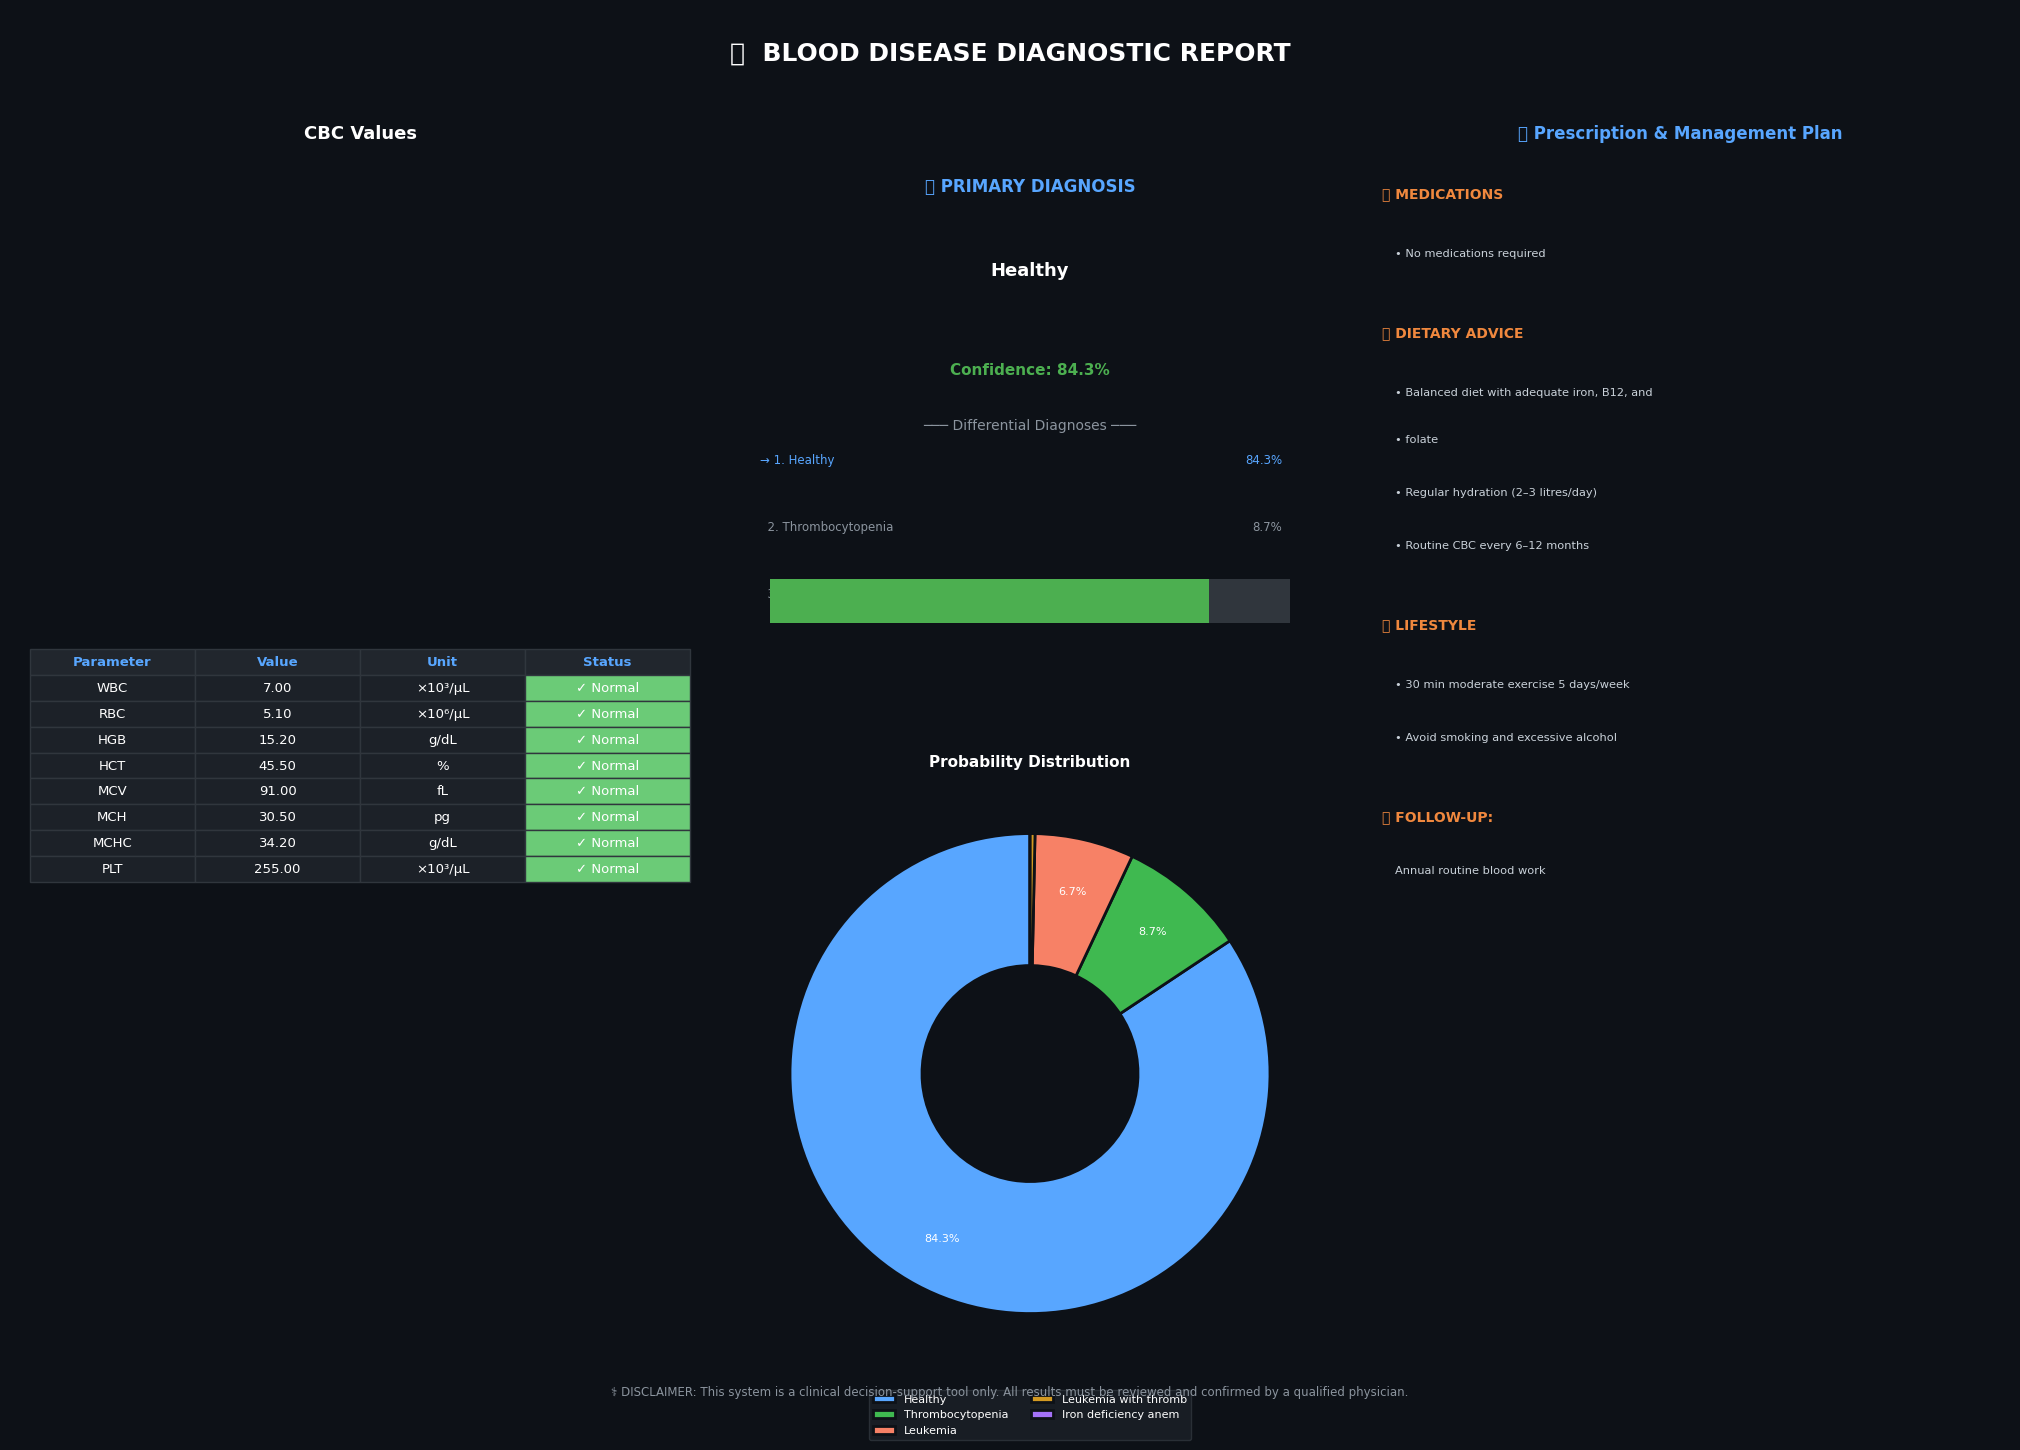


  🔬 DIAGNOSIS : Healthy
  📊 CONFIDENCE: 84.3%

  💊 KEY MEDICATIONS:
     • No medications required

  📅 FOLLOW-UP: Annual routine blood work


('Healthy', np.float64(0.8433333333333334))

In [23]:
# ── Demo 4: Healthy Normal ────────────────────────────────────────────
patient_NORMAL = {
    'WBC': 7.0,  'RBC': 5.1,  'HGB': 15.2, 'HCT': 45.5,
    'MCV': 91.0, 'MCH': 30.5, 'MCHC': 34.2,'PLT': 255.0,
    'NEU': 4.5,  'LYM': 2.5,  'MON': 0.5,  'EOS': 0.2,
    'BAS': 0.05, 'RDW': 12.4, 'MPV': 10.2
}
print("🧪 Demo Patient 4: Healthy / Normal")
diagnose_patient(patient_NORMAL)

🧪 Demo Patient 5: Thrombocytopenia


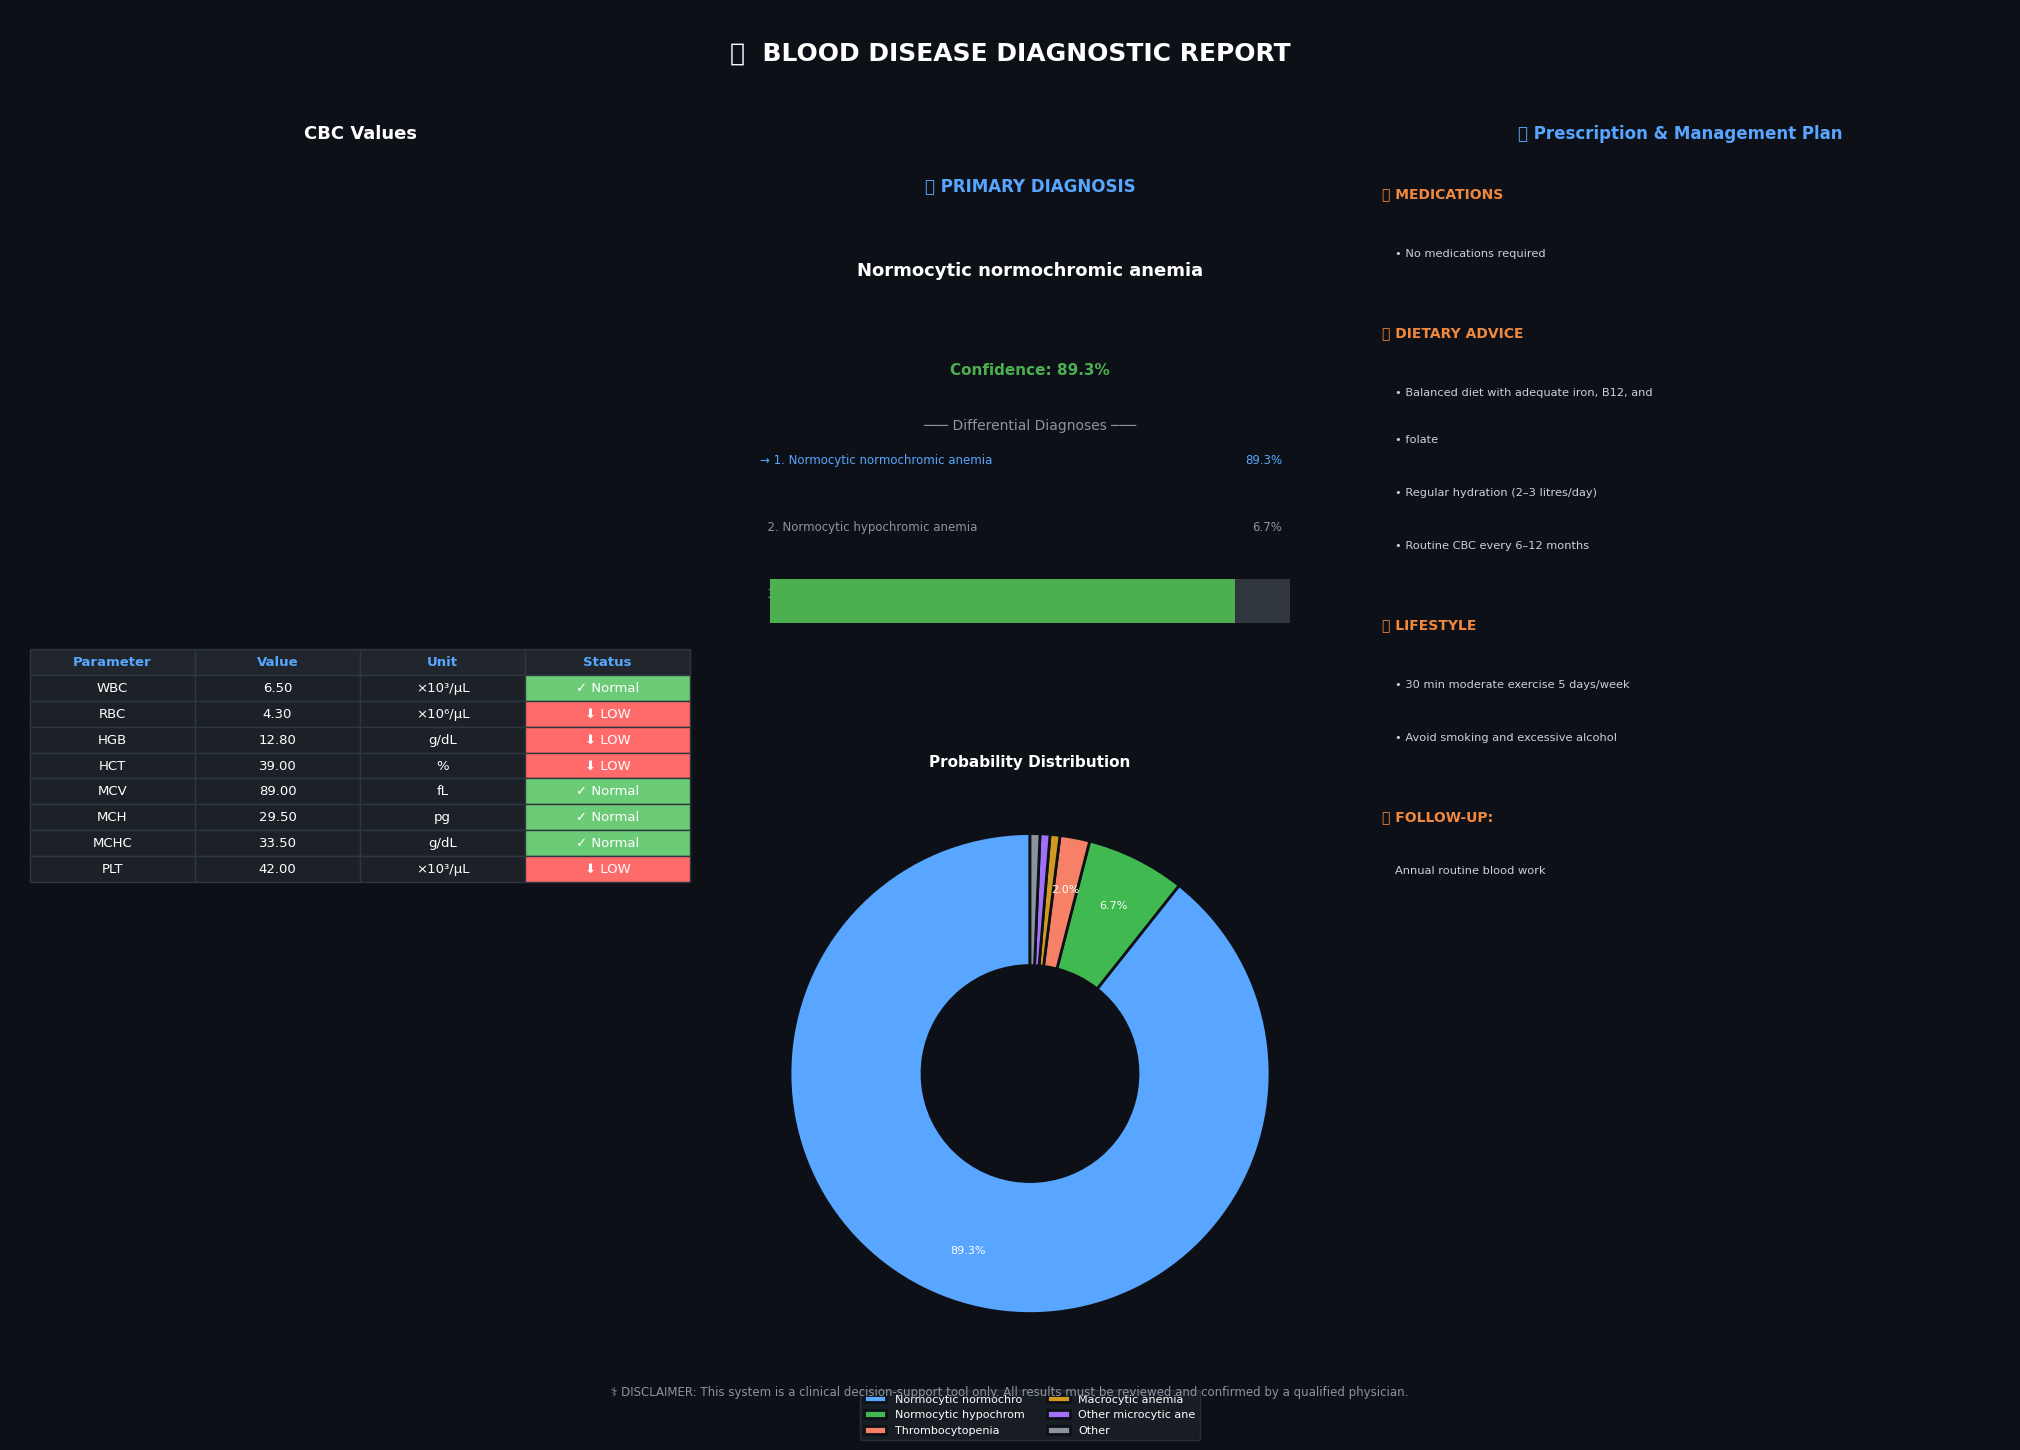


  🔬 DIAGNOSIS : Normocytic normochromic anemia
  📊 CONFIDENCE: 89.3%

  ⚠ ABNORMAL VALUES:
     ⬇ LOW RBC: 4.3 ×10⁶/µL  (normal: 4.5–5.5)
     ⬇ LOW HGB: 12.8 g/dL  (normal: 13.5–17.5)
     ⬇ LOW HCT: 39.0 %  (normal: 41.0–53.0)
     ⬇ LOW PLT: 42.0 ×10³/µL  (normal: 150.0–400.0)
     ⬆ HIGH MPV: 14.0 fL  (normal: 7.5–12.5)

  💊 KEY MEDICATIONS:
     • No medications required

  📅 FOLLOW-UP: Annual routine blood work


('Normocytic normochromic anemia', np.float64(0.8933333333333333))

In [24]:
# ── Demo 5: Thrombocytopenia ─────────────────────────────────────────
patient_THROM = {
    'WBC': 6.5,  'RBC': 4.3,  'HGB': 12.8, 'HCT': 39.0,
    'MCV': 89.0, 'MCH': 29.5, 'MCHC': 33.5,'PLT': 42.0,
    'NEU': 4.0,  'LYM': 2.0,  'MON': 0.4,  'EOS': 0.18,
    'BAS': 0.04, 'RDW': 13.1, 'MPV': 14.0
}
print("🧪 Demo Patient 5: Thrombocytopenia")
diagnose_patient(patient_THROM)

🧪 Demo Patient 6: B12 Deficiency Anemia


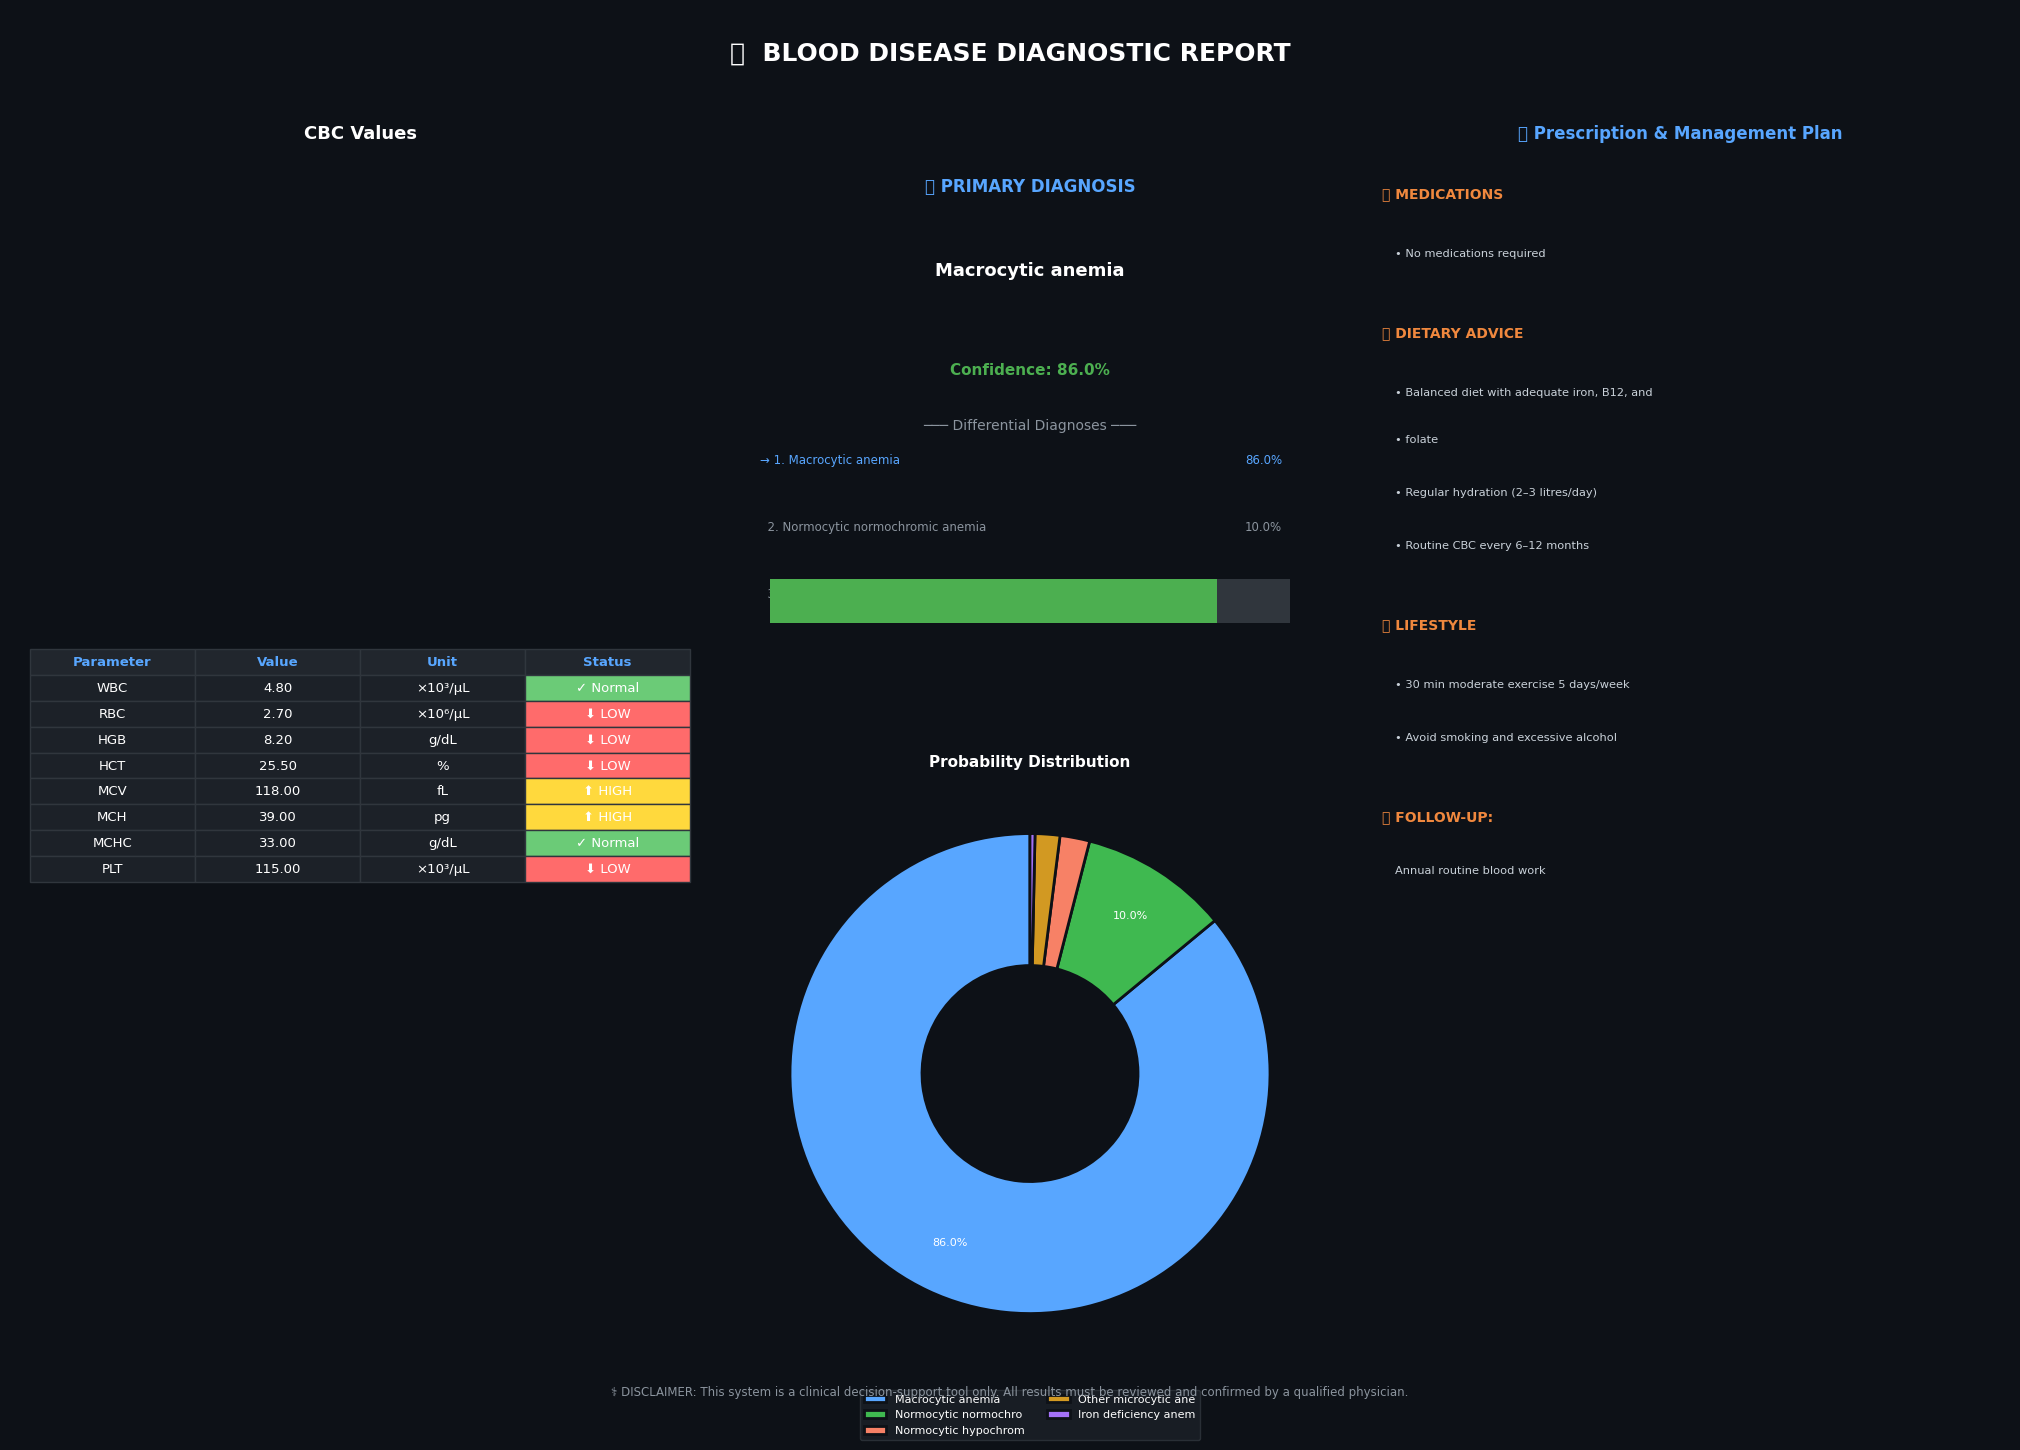


  🔬 DIAGNOSIS : Macrocytic anemia
  📊 CONFIDENCE: 86.0%

  ⚠ ABNORMAL VALUES:
     ⬇ LOW RBC: 2.7 ×10⁶/µL  (normal: 4.5–5.5)
     ⬇ LOW HGB: 8.2 g/dL  (normal: 13.5–17.5)
     ⬇ LOW HCT: 25.5 %  (normal: 41.0–53.0)
     ⬆ HIGH MCV: 118.0 fL  (normal: 80.0–100.0)
     ⬆ HIGH MCH: 39.0 pg  (normal: 27.0–33.0)
     ⬇ LOW PLT: 115.0 ×10³/µL  (normal: 150.0–400.0)

  💊 KEY MEDICATIONS:
     • No medications required

  📅 FOLLOW-UP: Annual routine blood work


('Macrocytic anemia', np.float64(0.86))

In [25]:
# ── Demo 6: B12 Deficiency Anemia ────────────────────────────────────
patient_B12 = {
    'WBC': 4.8,  'RBC': 2.7,  'HGB': 8.2,  'HCT': 25.5,
    'MCV': 118.0,'MCH': 39.0, 'MCHC': 33.0,'PLT': 115.0,
    'NEU': 3.2,  'LYM': 1.7,  'MON': 0.33, 'EOS': 0.11,
    'BAS': 0.03, 'RDW': 14.2, 'MPV': 9.3
}
print("🧪 Demo Patient 6: B12 Deficiency Anemia")
diagnose_patient(patient_B12)

## ✏️ Enter YOUR Patient's CBC Values
**Edit the dictionary below** with your patient's actual lab report values and run the cell.

📋 Patient CBC Values entered:
   RBC   :     5.00 ×10⁶/µL     
   HGB   :    15.50 g/dL        
   HCT   :    47.00 %           
   MCV   :    90.00 fL          
   MCH   :    30.00 pg          
   MCHC  :    34.00 g/dL        
   RDW   :    13.00 %           
   WBC   :     7.50 ×10³/µL     
   NEU   :     4.65 ×10³/µL     
   LYM   :     2.90 ×10³/µL     
   MON   :     0.60 ×10³/µL     
   EOS   :     0.25 ×10³/µL     
   BAS   :     0.05 ×10³/µL     
   PLT   :   275.00 ×10³/µL     
   MPV   :    10.00 fL          

Running diagnosis...


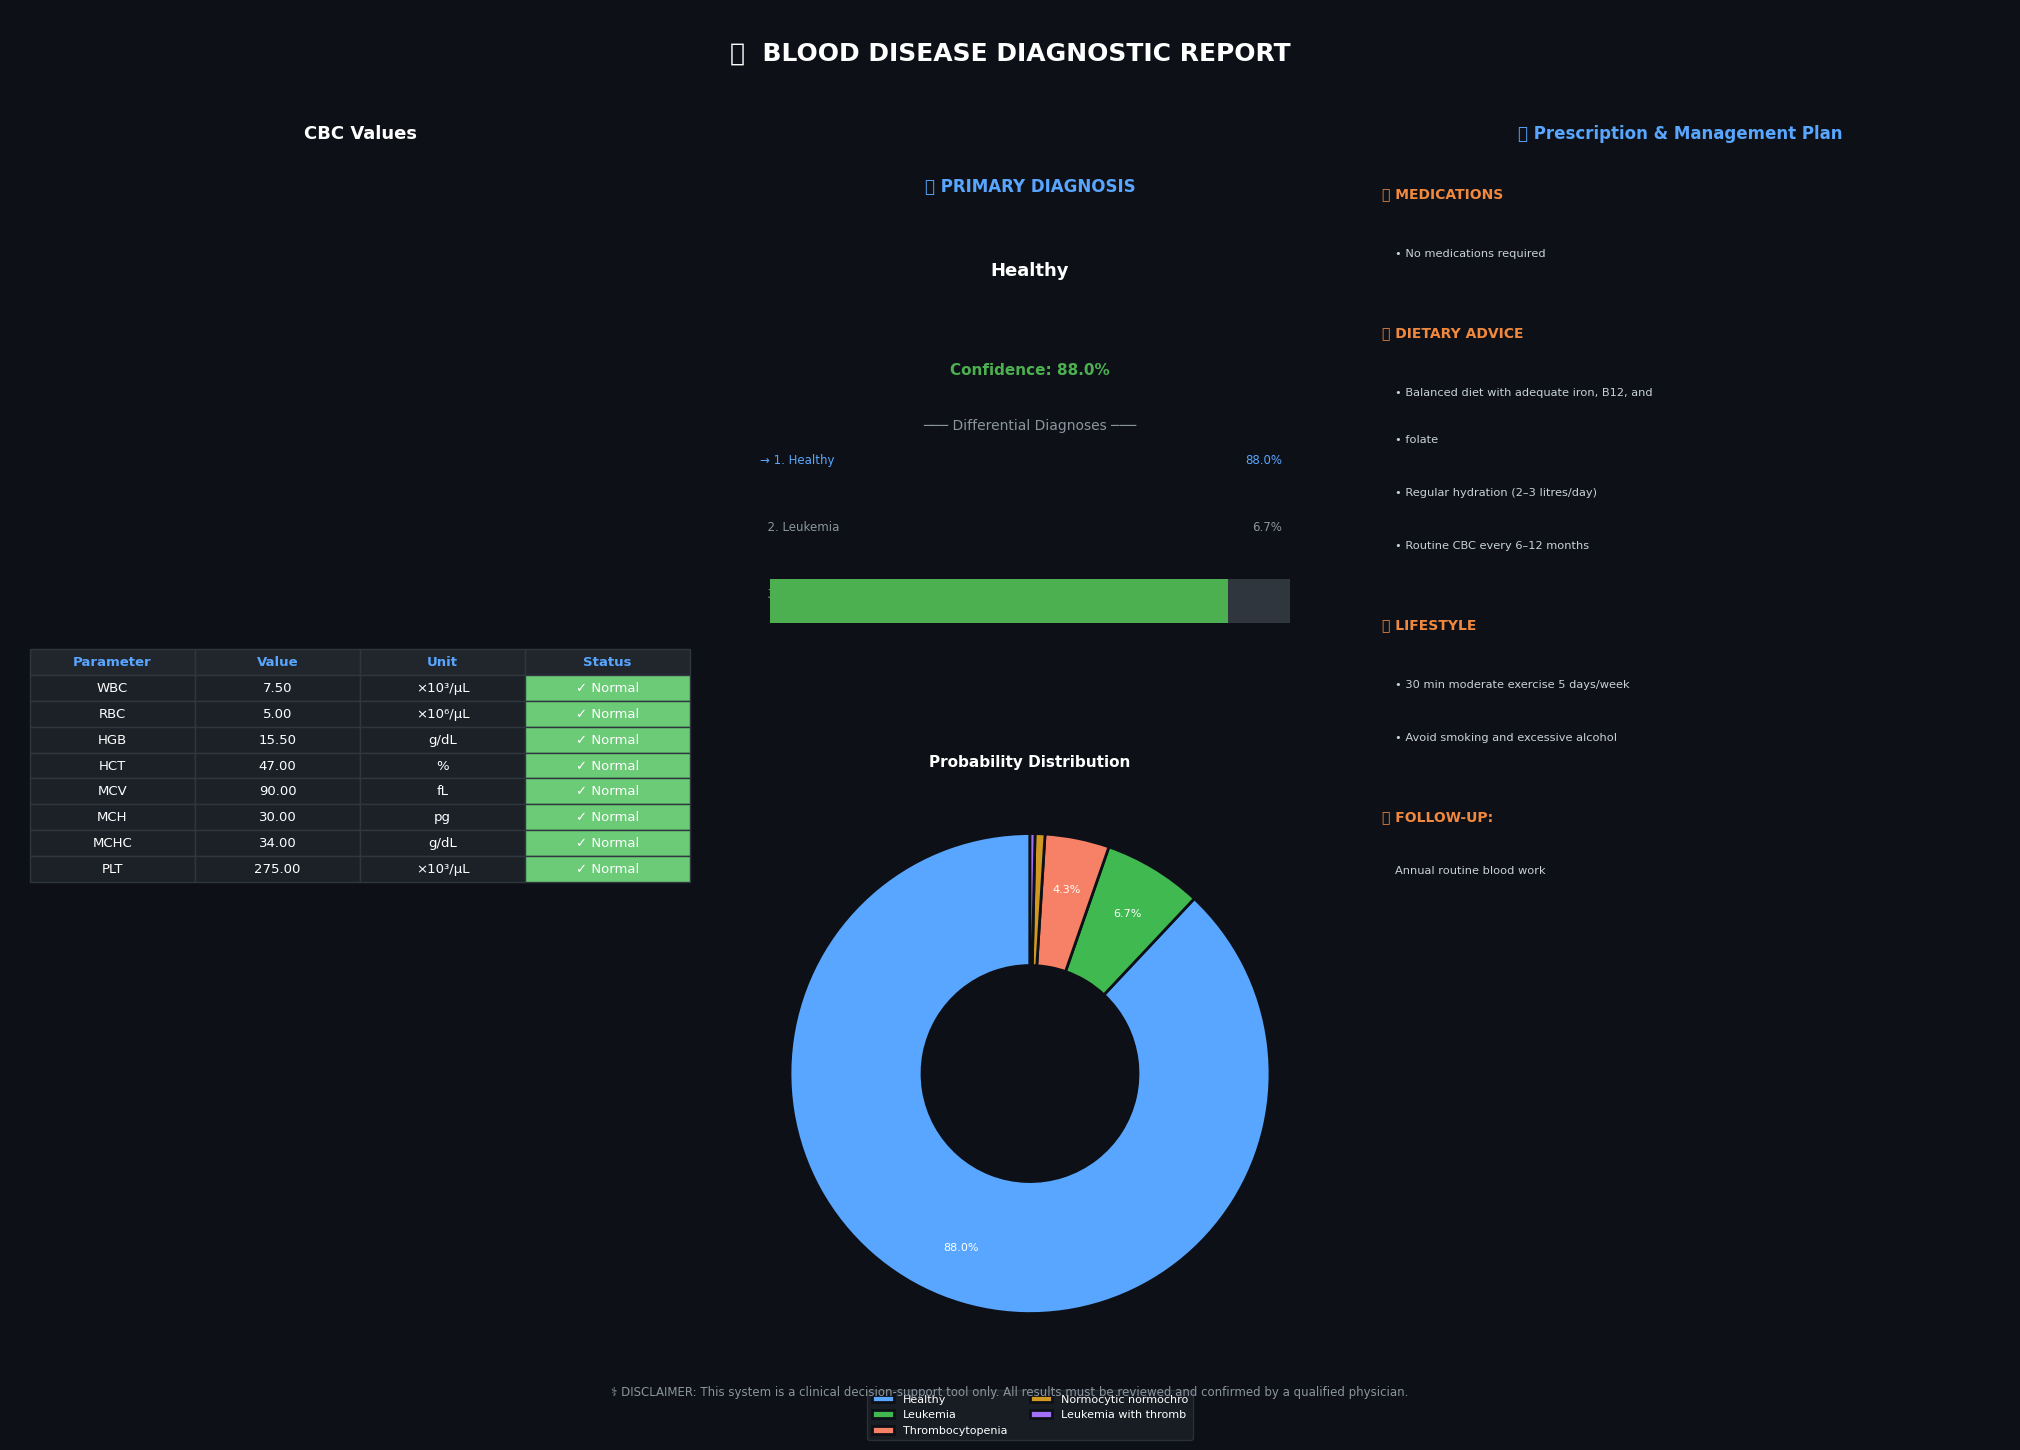


  🔬 DIAGNOSIS : Healthy
  📊 CONFIDENCE: 88.0%

  💊 KEY MEDICATIONS:
     • No medications required

  📅 FOLLOW-UP: Annual routine blood work


('Healthy', np.float64(0.88))

In [26]:
# ════════════════════════════════════════════════════════════
#  ✏️  FILL IN YOUR PATIENT'S VALUES BELOW
#     Leave a value as None to use the midpoint of normal range
# ════════════════════════════════════════════════════════════

MY_PATIENT = {
    # ─── Red Cell Parameters ──────────────────────────────────
    'RBC':  None,    # ×10⁶/µL   Normal: 4.5 – 5.5
    'HGB':  None,    # g/dL       Normal: 13.5 – 17.5
    'HCT':  None,    # %          Normal: 41.0 – 53.0
    'MCV':  None,    # fL         Normal: 80.0 – 100.0
    'MCH':  None,    # pg         Normal: 27.0 – 33.0
    'MCHC': None,    # g/dL       Normal: 32.0 – 36.0
    'RDW':  None,    # %          Normal: 11.5 – 14.5

    # ─── White Cell Parameters ────────────────────────────────
    'WBC':  None,    # ×10³/µL   Normal: 4.0 – 11.0
    'NEU':  None,    # ×10³/µL   Normal: 1.8 – 7.5
    'LYM':  None,    # ×10³/µL   Normal: 1.0 – 4.8
    'MON':  None,    # ×10³/µL   Normal: 0.2 – 1.0
    'EOS':  None,    # ×10³/µL   Normal: 0.0 – 0.5
    'BAS':  None,    # ×10³/µL   Normal: 0.0 – 0.1

    # ─── Platelet Parameters ──────────────────────────────────
    'PLT':  None,    # ×10³/µL   Normal: 150.0 – 400.0
    'MPV':  None,    # fL         Normal: 7.5 – 12.5
}

# Replace None with the midpoint of normal range
for key, val in MY_PATIENT.items():
    if val is None and key in NORMAL_RANGES:
        lo, hi, _ = NORMAL_RANGES[key]
        MY_PATIENT[key] = round((lo + hi) / 2, 2)

print("📋 Patient CBC Values entered:")
for k, v in MY_PATIENT.items():
    lo, hi, unit = NORMAL_RANGES.get(k, (0,9999,''))
    flag = ' ⬇LOW' if v < lo else ' ⬆HIGH' if v > hi else ''
    print(f"   {k:<6}: {v:>8.2f} {unit:<12}{flag}")

print("\nRunning diagnosis...")
diagnose_patient(MY_PATIENT)

## 💾 Files Saved to Google Drive

In [27]:
print("📁 Files saved to your Google Drive:")
print(f"\n  📂 {PROJECT_DIR}")
for root, dirs, files in os.walk(PROJECT_DIR):
    level = root.replace(PROJECT_DIR, '').count(os.sep)
    indent = '  ' + '│  ' * level + '├─ '
    print(f"{indent}{os.path.basename(root)}/")
    sub_indent = '  ' + '│  ' * (level+1) + '├─ '
    for file in files:
        fpath = os.path.join(root, file)
        size  = os.path.getsize(fpath)
        print(f"{sub_indent}{file}  ({size/1024:.1f} KB)")

print("\n✅ Everything is saved. Re-running this notebook will load cached model and data from Drive.")

📁 Files saved to your Google Drive:

  📂 /content/drive/MyDrive/BloodDiseaseML
  ├─ BloodDiseaseML/
  │  ├─ data/
  │  │  ├─ diagnosed_cbc_data_v4.csv  (122.6 KB)
  │  │  ├─ blood_disease_dataset.csv  (78.9 KB)
  │  ├─ models/
  │  │  ├─ best_model.pkl  (7997.0 KB)
  │  │  ├─ model_meta.pkl  (0.3 KB)
  │  ├─ plots/
  │  │  ├─ eda_plots.png  (136.2 KB)
  │  │  ├─ correlation_heatmap.png  (70.1 KB)
  │  │  ├─ evaluation_dashboard.png  (338.4 KB)
  │  │  ├─ patient_report.png  (250.5 KB)

✅ Everything is saved. Re-running this notebook will load cached model and data from Drive.
